# Results reviewer

Coal installed-capacity diagnostics for `dataset_north_sea`.

In [2]:
# ── Dataset configuration ────────────────────────────────────────────
# Set DATASET_NAME to the folder name inside Results/basic_run/ that you want to review.
from pathlib import Path

# DATASET_NAME = "dataset_NS_REPowerEU++"  # <-- change this to switch datasets
# DATASET_NAME = "dataset_NS_trinity"
# DATASET_NAME = "dataset_NS_GoRES"
# DATASET_NAME = "dataset_ES_GoRES"

# DATASET_NAME = "dataset_NS_REPowerEU++"  # <-- change this to switch datasets
# DATASET_NAME = "dataset_NESP_trinity"
# DATASET_NAME = "dataset_NS_GoRES"
DATASET_NAME = "dataset_ES_GoRES"

YEAR_SHIFT = 5  # Add this many years to all period labels (0 = no shift);
                # 5 shifts the original NUTS-2 labels to align with the
                # aggregated runs (e.g. 2020-2025 -> 2025-2030)

RESULTS_BASE = Path('../Results/basic_run')
DATASET_PATH = RESULTS_BASE / DATASET_NAME
COORDS_FILE  = DATASET_PATH / 'Input' / 'Xlsx' / 'Sets.xlsx'

# Create plots output directory next to the dataset results
PLOT_DIR = DATASET_PATH / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Dataset : {DATASET_NAME}')
print(f'Results : {DATASET_PATH.resolve()}')
print(f'Plots   : {PLOT_DIR.resolve()}')


Dataset : dataset_ES_GoRES
Results : C:\Users\ehsanno\DataspellProjects\OpenEMPIRE_NS\Results\basic_run\dataset_ES_GoRES
Plots   : C:\Users\ehsanno\DataspellProjects\OpenEMPIRE_NS\Results\basic_run\dataset_ES_GoRES\plots


In [3]:
from pathlib import Path
import re
import pandas as pd


def shift_period_label(label: str, shift: int) -> str:
    """Shift all 4-digit year numbers in a period label string."""
    if shift == 0:
        return str(label)
    return re.sub(r'\d{4}', lambda m: str(int(m.group()) + shift), str(label))

def period_end_year(period_label: str) -> int:
    years = re.findall(r"\d{4}", str(period_label))
    return int(years[-1]) if years else -1

results_path = DATASET_PATH / 'Output' / 'results_output_gen.csv'
df = pd.read_csv(results_path)
if YEAR_SHIFT:
    df['Period'] = df['Period'].astype(str).map(lambda x: shift_period_label(x, YEAR_SHIFT))

required = {'Node', 'GeneratorType', 'Period', 'genInstalledCap_MW'}
missing = required - set(df.columns)
if missing:
    raise ValueError(f'Missing columns in {results_path}: {sorted(missing)}')

# Keep coal-related technologies (coal, lignite, hard-coal naming variants).
coal_mask = df['GeneratorType'].astype(str).str.contains(r'coal|lignite|hcoal|hardcoal', case=False, regex=True)
coal_df = df.loc[coal_mask].copy()

if coal_df.empty:
    print('No coal-related technologies found in results_output_gen.csv')
else:
    coal_df['genInstalledCap_MW'] = pd.to_numeric(coal_df['genInstalledCap_MW'], errors='coerce').fillna(0.0)

    period_order = sorted(coal_df['Period'].astype(str).unique().tolist(), key=period_end_year)
    p_first = period_order[0]
    p_last = period_order[-1]

    print('Coal-related technologies detected:')
    print(sorted(coal_df['GeneratorType'].dropna().unique().tolist()))

    print('\n1) Installed capacity by coal technology and period [MW]')
    by_tech_period = (
        coal_df.groupby(['GeneratorType', 'Period'], as_index=False)['genInstalledCap_MW']
        .sum()
    )
    by_tech_period['period_sort'] = by_tech_period['Period'].map(period_end_year)
    by_tech_period = by_tech_period.sort_values(['GeneratorType', 'period_sort', 'Period']).drop(columns=['period_sort'])
    display(by_tech_period)

    print('\n2) Aggregated coal installed capacity (all coal technologies) by period [MW]')
    agg_period = (
        coal_df.groupby('Period', as_index=False)['genInstalledCap_MW']
        .sum()
        .rename(columns={'genInstalledCap_MW': 'coal_total_installed_MW'})
    )
    agg_period['period_sort'] = agg_period['Period'].map(period_end_year)
    agg_period = agg_period.sort_values(['period_sort', 'Period']).drop(columns=['period_sort'])
    display(agg_period)

    print('\n3) Aggregated coal installed capacity by node and period [MW] (top 50 rows)')
    by_node_period = (
        coal_df.groupby(['Node', 'Period'], as_index=False)['genInstalledCap_MW']
        .sum()
        .rename(columns={'genInstalledCap_MW': 'coal_total_installed_MW'})
    )
    by_node_period['period_sort'] = by_node_period['Period'].map(period_end_year)
    by_node_period = by_node_period.sort_values(['period_sort', 'coal_total_installed_MW'], ascending=[True, False]).drop(columns=['period_sort'])
    display(by_node_period.head(50))

    print('\n4) Change from first to last period by coal technology [MW]')
    first_last = by_tech_period[by_tech_period['Period'].isin([p_first, p_last])].copy()
    first_last = first_last.pivot(index='GeneratorType', columns='Period', values='genInstalledCap_MW').fillna(0.0)
    if p_first not in first_last.columns:
        first_last[p_first] = 0.0
    if p_last not in first_last.columns:
        first_last[p_last] = 0.0
    first_last['delta_MW_last_minus_first'] = first_last[p_last] - first_last[p_first]
    first_last = first_last.reset_index().sort_values('delta_MW_last_minus_first', ascending=False)
    display(first_last)


Coal-related technologies detected:
['Coal', 'CoalCCS', 'Lignite', 'LigniteCCS']

1) Installed capacity by coal technology and period [MW]


,GeneratorType,Period,genInstalledCap_MW
0,Coal,2025-2030,61704.910067
1,Coal,2030-2035,48874.344546
2,CoalCCS,2025-2030,0.000045
3,CoalCCS,2030-2035,0.000072
4,Lignite,2025-2030,52316.560307
5,Lignite,2030-2035,32369.451154
6,LigniteCCS,2025-2030,0.000019
7,LigniteCCS,2030-2035,0.000030



2) Aggregated coal installed capacity (all coal technologies) by period [MW]


,Period,coal_total_installed_MW
0,2025-2030,114021.470438
1,2030-2035,81243.795802



3) Aggregated coal installed capacity by node and period [MW] (top 50 rows)


,Node,Period,coal_total_installed_MW
114,Germany,2025-2030,36774.000009
134,Poland,2025-2030,26387.510006
10,CzechR,2025-2030,8400.000005
140,Serbia,2025-2030,6010.500000
124,Italy,2025-2030,5583.000003
6,Bulgaria,2025-2030,4475.000005
132,Netherlands,2025-2030,4006.000002
12,Denmark,2025-2030,3165.000003
118,Greece,2025-2030,2650.000000
142,Slovakia,2025-2030,2411.000011



4) Change from first to last period by coal technology [MW]


Period,GeneratorType,2025-2030,2030-2035,delta_MW_last_minus_first
1,CoalCCS,0.000045,0.000072,0.000027
3,LigniteCCS,0.000019,0.000030,0.000011
0,Coal,61704.910067,48874.344546,-12830.565521
2,Lignite,52316.560307,32369.451154,-19947.109153


Period,Node,delta_MW_last_minus_first
0,Belgium,0.000010
1,Austria,0.000008
2,Latvia,0.000007
3,Sweden,0.000006
4,Portugal,0.000004
...,...,...
69,Bulgaria,-1644.505208
70,Serbia,-2291.666353
71,CzechR,-2994.716655
72,Poland,-6796.819870


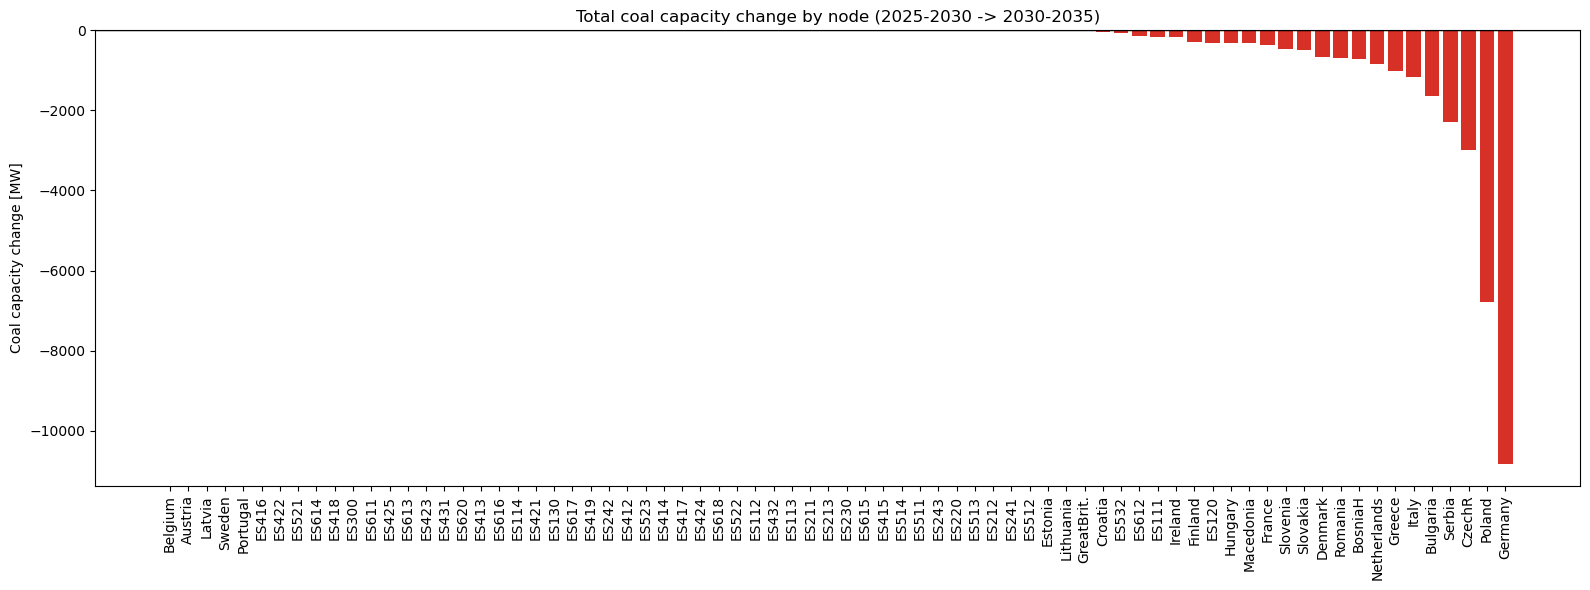

In [4]:
import matplotlib.pyplot as plt

if coal_df.empty:
    print('No coal data available for plotting.')
else:
    # Total coal change by node: last period - first period
    coal_by_node_period = (
        coal_df.groupby(['Node', 'Period'], as_index=False)['genInstalledCap_MW']
        .sum()
        .rename(columns={'genInstalledCap_MW': 'coal_total_installed_MW'})
    )

    period_order = sorted(coal_by_node_period['Period'].astype(str).unique().tolist(), key=period_end_year)
    p_first = period_order[0]
    p_last = period_order[-1]

    node_change = (
        coal_by_node_period[coal_by_node_period['Period'].isin([p_first, p_last])]
        .pivot(index='Node', columns='Period', values='coal_total_installed_MW')
        .fillna(0.0)
    )
    if p_first not in node_change.columns:
        node_change[p_first] = 0.0
    if p_last not in node_change.columns:
        node_change[p_last] = 0.0
    node_change['delta_MW_last_minus_first'] = node_change[p_last] - node_change[p_first]
    node_change = node_change.sort_values('delta_MW_last_minus_first', ascending=False)

    display(node_change[['delta_MW_last_minus_first']].reset_index())

    plt.figure(figsize=(16, 6))
    colors = ['#1a9850' if v >= 0 else '#d73027' for v in node_change['delta_MW_last_minus_first']]
    plt.bar(node_change.index, node_change['delta_MW_last_minus_first'], color=colors)
    plt.axhline(0.0, color='black', linewidth=1.0)
    plt.xticks(rotation=90)
    plt.ylabel('Coal capacity change [MW]')
    plt.title(f'Total coal capacity change by node ({p_first} -> {p_last})')
    plt.tight_layout()
    plt.savefig(PLOT_DIR / 'coal_capacity_change_by_node.png', dpi=150, bbox_inches='tight')
    plt.show()


## Map Plots

Installed-capacity pies, capacity-change bars, and expected load-curtailment bubbles for `dataset_north_sea`, adapted from `plot.py` for inline display.

In [5]:
from __future__ import annotations

import json
import re
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Wedge
from shapely.geometry import shape

%matplotlib inline

# Paths?
RESULTS_PATH = DATASET_PATH
BASEMAP_FILE = Path('NUTS_RG_60M_2024_3035.geojson')

# Aggregation flag?
AGGREGATE_OFFSHORE_TO_CLOSEST_ONSHORE = True

# Focused area selection
# Choose one of: "North Sea region", "Nordic region" or "Spain".
FOCUSED_AREA = "Spain"

FOCUSED_AREA_COUNTRIES = {
    "North Sea region": ("NO", "DE", "NL", "DK", "UK"),
    "Nordic region": ("NO", "SE", "FI", "DK"),
    "Spain": ("ES",),
}
COUNTRY_CODE_ALIASES = {
    "UK": ("UK", "GB"),
}

if FOCUSED_AREA not in FOCUSED_AREA_COUNTRIES:
    raise ValueError(
        f"Unknown FOCUSED_AREA={FOCUSED_AREA!r}. "
        f"Choose one of: {', '.join(FOCUSED_AREA_COUNTRIES)}"
    )

FOCUSED_COUNTRIES = tuple(FOCUSED_AREA_COUNTRIES[FOCUSED_AREA])
NUTS2_COUNTRIES = {
    alias
    for country_code in FOCUSED_COUNTRIES
    for alias in COUNTRY_CODE_ALIASES.get(country_code, (country_code,))
}
FOCUSED_COUNTRY_LABEL = ", ".join(FOCUSED_COUNTRIES)

print(f"Focused area: {FOCUSED_AREA} ({FOCUSED_COUNTRY_LABEL})")

# Technology display order and colours
TECH_ORDER = ["Lignite","Hcoal","Coal","Gas","Oil","Bio","Geo","Nuclear","Hydro","Wave","Wind","Solar","Waste"]
TECH_COLORS = {
    "Lignite": "#7f7f7f", "Hcoal": "#4f4f4f",  "Coal":    "#9a9a9a",
    "Gas":     "#d62728", "Oil":   "#8c564b",   "Bio":     "#2ca02c",
    "Geo":     "#ff9896", "Nuclear":"#e377c2",  "Hydro":   "#17becf",
    "Wave":    "#1f9ed4", "Wind":  "#1f77b4",   "Solar":   "#ffbb00",
    "Waste":   "#bcbd22",
}
CHANGE_GROUPS = {
    "renewable_generation":                ["Bio","Geo","Hydro","Wave","Wind","Solar","Waste"],
    "thermal_generation_including_nuclear": ["Lignite","Hcoal","Coal","Gas","Oil","Nuclear"],
    "coal":                                ["Lignite","Hcoal","Coal"],
    "wind_and_solar":                      ["Wind","Solar"],
    "hydro":                               ["Hydro"],
}
GEOJSON_SOURCE_CRS = ccrs.epsg(3035)


Focused area: Spain (ES)


In [6]:
# ── Helper functions (from plot.py) ───────────────────────

def normalize_name(value: str) -> str:
    return re.sub(r"[^a-z0-9]+", "", str(value).strip().lower())


def load_coords(coords_file: Path) -> pd.DataFrame:
    coords = pd.read_excel(coords_file, sheet_name="Coords", skiprows=2, usecols=[0, 1, 2])
    coords.columns = ["Location", "Latitude", "Longitude"]
    coords = coords.dropna(subset=["Location", "Latitude", "Longitude"]).copy()
    coords["norm_node"] = coords["Location"].map(normalize_name)
    return coords


def load_offshore_nodes(results_path: Path) -> set[str]:
    offshore_file = results_path / "Input" / "Tab" / "Sets_OffshoreNode.tab"
    if not offshore_file.exists():
        return set()
    offshore = pd.read_csv(offshore_file, sep="\t", header=None, names=["Node"])
    offshore["Node"] = offshore["Node"].astype(str).str.strip()
    offshore = offshore[offshore["Node"] != ""].copy()
    offshore["norm_node"] = offshore["Node"].map(normalize_name)
    offshore = offshore[offshore["norm_node"] != "offshorenode"]
    return set(offshore["norm_node"].tolist())


def build_offshore_to_onshore_map(coords: pd.DataFrame, offshore_norm_nodes: set[str]) -> dict[str, str]:
    if not offshore_norm_nodes:
        return {}
    coord_lookup = coords[["norm_node", "Latitude", "Longitude"]].drop_duplicates("norm_node")
    onshore_coords = coord_lookup.loc[~coord_lookup["norm_node"].isin(offshore_norm_nodes)].copy()
    offshore_coords = coord_lookup.loc[coord_lookup["norm_node"].isin(offshore_norm_nodes)].copy()
    if onshore_coords.empty or offshore_coords.empty:
        return {}
    nearest_map: dict[str, str] = {}
    for _, row in offshore_coords.iterrows():
        d2 = (onshore_coords["Latitude"] - row["Latitude"]) ** 2 + (onshore_coords["Longitude"] - row["Longitude"]) ** 2
        nearest_idx = d2.idxmin()
        nearest_map[str(row["norm_node"])] = str(onshore_coords.loc[nearest_idx, "norm_node"])
    return nearest_map


def aggregate_offshore_to_nearest_onshore(
    capacity: pd.DataFrame,
    coords: pd.DataFrame,
    offshore_norm_nodes: set[str],
    offshore_to_onshore: dict[str, str] | None = None,
) -> pd.DataFrame:
    if not offshore_norm_nodes:
        return capacity
    coord_lookup = coords[["norm_node", "Location", "Latitude", "Longitude"]].drop_duplicates("norm_node")
    if offshore_to_onshore is None:
        offshore_to_onshore = build_offshore_to_onshore_map(coords, offshore_norm_nodes)
    if not offshore_to_onshore:
        return capacity
    cap = capacity.copy()
    cap["target_norm_node"] = cap["norm_node"].map(offshore_to_onshore).fillna(cap["norm_node"])
    grouped = cap.groupby("target_norm_node", as_index=False)[TECH_ORDER].sum()
    grouped = grouped.rename(columns={"target_norm_node": "norm_node"})
    grouped["total_cap"] = grouped[TECH_ORDER].sum(axis=1)
    name_map = coord_lookup.set_index("norm_node")["Location"].to_dict()
    grouped["Node"] = grouped["norm_node"].map(name_map).fillna(grouped["norm_node"])
    return grouped[["Node", *TECH_ORDER, "total_cap", "norm_node"]]


def load_transmission_by_period(results_path: Path) -> tuple[dict[str, pd.DataFrame], list[str]]:
    """Load installed transmission capacity per period from results_output_transmision.csv."""
    csv_file = results_path / "Output" / "results_output_transmision.csv"
    lines = pd.read_csv(csv_file)
    required = {"BetweenNode", "AndNode", "Period", "transmissionInstalledCap_MW"}
    missing = required - set(lines.columns)
    if missing:
        raise ValueError(f"Missing columns in {csv_file}: {sorted(missing)}")

    lines["transmissionInstalledCap_MW"] = pd.to_numeric(lines["transmissionInstalledCap_MW"], errors="coerce").fillna(0.0)
    lines = lines.dropna(subset=["BetweenNode", "AndNode", "Period"]).copy()
    lines["Period"] = lines["Period"].astype(str)
    if YEAR_SHIFT:
        lines["Period"] = lines["Period"].map(lambda x: shift_period_label(x, YEAR_SHIFT))
    lines["from_norm"] = lines["BetweenNode"].map(normalize_name)
    lines["to_norm"]   = lines["AndNode"].map(normalize_name)

    # Canonical undirected key to avoid plotting both A→B and B→A.
    lines["u"] = np.where(lines["from_norm"] <= lines["to_norm"], lines["from_norm"], lines["to_norm"])
    lines["v"] = np.where(lines["from_norm"] <= lines["to_norm"], lines["to_norm"], lines["from_norm"])
    lines = lines.groupby(["Period", "u", "v"], as_index=False)["transmissionInstalledCap_MW"].max()

    periods = sorted(lines["Period"].unique().tolist(), key=parse_period_end_year)
    by_period: dict[str, pd.DataFrame] = {
        p: lines.loc[lines["Period"] == p, ["u", "v", "transmissionInstalledCap_MW"]].copy()
        for p in periods
    }
    # Rename for downstream compatibility
    for p in periods:
        by_period[p] = by_period[p].rename(columns={"transmissionInstalledCap_MW": "transmissionInstalledCap"})
    return by_period, periods


def map_generator_to_group(generator: str) -> str | None:
    g = str(generator).strip().lower()
    if "lignite" in g:            return "Lignite"
    if "hardcoal" in g or g == "hcoal" or "hcoal" in g: return "Hcoal"
    if "coal" in g:               return "Coal"
    if "gas" in g:                return "Gas"
    if "oil" in g:                return "Oil"
    if "bio" in g:                return "Bio"
    if "geo" in g:                return "Geo"
    if "nuclear" in g:            return "Nuclear"
    if "hydro" in g:              return "Hydro"
    if "wave" in g:               return "Wave"
    if "wind" in g:               return "Wind"
    if "solar" in g:              return "Solar"
    if "waste" in g:              return "Waste"
    return None


def parse_period_end_year(value: str) -> int:
    years = re.findall(r"\d{4}", str(value))
    return int(years[-1]) if years else -1


def load_capacity_by_period(results_path: Path) -> tuple[dict[str, pd.DataFrame], list[str]]:
    """Load installed generation capacity per period from results_output_gen.csv."""
    csv_file = results_path / "Output" / "results_output_gen.csv"
    gen = pd.read_csv(csv_file)
    required = {"Node", "GeneratorType", "Period", "genInstalledCap_MW"}
    missing = required - set(gen.columns)
    if missing:
        raise ValueError(f"Missing columns in {csv_file}: {sorted(missing)}")

    gen["genInstalledCap_MW"] = pd.to_numeric(gen["genInstalledCap_MW"], errors="coerce").fillna(0.0)
    gen = gen.dropna(subset=["Node", "GeneratorType", "Period"]).copy()
    gen["Period"] = gen["Period"].astype(str)
    if YEAR_SHIFT:
        gen["Period"] = gen["Period"].map(lambda x: shift_period_label(x, YEAR_SHIFT))

    gen["TechGroup"] = gen["GeneratorType"].map(map_generator_to_group)
    unknown = sorted(gen.loc[gen["TechGroup"].isna(), "GeneratorType"].astype(str).unique())
    if unknown:
        print("Warning: Unmapped technologies skipped:", ", ".join(unknown))
    gen = gen.dropna(subset=["TechGroup"])

    cap_all = gen.groupby(["Period", "Node", "TechGroup"], as_index=False)["genInstalledCap_MW"].sum()
    print("Unique technologies in dataset:", ", ".join(sorted(gen["GeneratorType"].astype(str).unique())))

    periods = sorted(cap_all["Period"].unique().tolist(), key=parse_period_end_year)
    by_period: dict[str, pd.DataFrame] = {}
    for period in periods:
        cap = (
            cap_all.loc[cap_all["Period"] == period, ["Node", "TechGroup", "genInstalledCap_MW"]]
            .pivot(index="Node", columns="TechGroup", values="genInstalledCap_MW")
            .fillna(0.0).reset_index()
        )
        for tech in TECH_ORDER:
            if tech not in cap.columns:
                cap[tech] = 0.0
        cap["total_cap"] = cap[TECH_ORDER].sum(axis=1)
        cap["norm_node"] = cap["Node"].map(normalize_name)
        by_period[period] = cap
    return by_period, periods


def load_load_curtailment_last_period(results_path: Path) -> tuple[pd.DataFrame, str]:
    curtail_file = results_path / "Output" / "results_output_Operational.csv"
    curtail = pd.read_csv(curtail_file)
    curtail["LoadShed_MW"] = pd.to_numeric(curtail["LoadShed_MW"], errors="coerce").fillna(0.0)
    if YEAR_SHIFT:
        curtail["Period"] = curtail["Period"].astype(str).map(lambda x: shift_period_label(x, YEAR_SHIFT))
    periods = sorted(curtail["Period"].astype(str).unique().tolist(), key=parse_period_end_year)
    last_period = periods[-1]
    curtail_last = (
        curtail.loc[curtail["Period"].astype(str) == last_period, ["Node", "Scenario", "LoadShed_MW"]]
        .groupby(["Node", "Scenario"], as_index=False)["LoadShed_MW"].sum()
        .groupby("Node", as_index=False)["LoadShed_MW"].mean()
    )
    curtail_last["ExpectedLoadCurtailment_GWh"] = curtail_last["LoadShed_MW"] / 1000.0
    curtail_last = curtail_last[["Node", "ExpectedLoadCurtailment_GWh"]]
    curtail_last["norm_node"] = curtail_last["Node"].map(normalize_name)
    return curtail_last, last_period


def load_geojson_geometries(geojson_file: Path) -> list:
    with geojson_file.open("r", encoding="utf-8") as f:
        payload = json.load(f)
    return [shape(feat["geometry"]) for feat in payload.get("features", []) if feat.get("geometry")]


def load_nuts2_country_borders(geojson_file: Path, country_codes: set[str]) -> list:
    with geojson_file.open("r", encoding="utf-8") as f:
        payload = json.load(f)
    borders = []
    for feat in payload.get("features", []):
        geom = feat.get("geometry")
        props = feat.get("properties", {})
        if not geom:
            continue
        cntr = str(props.get("CNTR_CODE", "")).strip().upper()
        try:
            level = int(props.get("LEVL_CODE"))
        except (TypeError, ValueError):
            level = None
        if cntr in country_codes and level == 2:
            borders.append(shape(geom))
    return borders


def available_nuts2_country_codes(geojson_payload: dict) -> set[str]:
    codes = set()
    for feat in geojson_payload.get("features", []):
        props = feat.get("properties", {})
        try:
            level = int(props.get("LEVL_CODE"))
        except (TypeError, ValueError):
            continue
        if level == 2:
            codes.add(str(props.get("CNTR_CODE", "")).strip().upper())
    return codes


def missing_focus_nuts2_countries(available_codes: set[str]) -> list[str]:
    missing = []
    for country_code in FOCUSED_COUNTRIES:
        aliases = set(COUNTRY_CODE_ALIASES.get(country_code, (country_code,)))
        if not aliases.intersection(available_codes):
            missing.append(country_code)
    return missing


def build_change_dataframe(first_cap: pd.DataFrame, last_cap: pd.DataFrame, group_techs: list[str]) -> pd.DataFrame:
    first = first_cap[["norm_node", *group_techs]].copy()
    last  = last_cap[["norm_node", *group_techs]].copy()
    first["first_value"] = first[group_techs].sum(axis=1)
    last["last_value"]   = last[group_techs].sum(axis=1)
    merged = (
        first[["norm_node", "first_value"]]
        .merge(last[["norm_node", "last_value"]], on="norm_node", how="outer")
        .fillna(0.0)
    )
    merged["delta_mw"] = merged["last_value"] - merged["first_value"]
    return merged[["norm_node", "delta_mw"]]

print("Helper functions loaded.")


Helper functions loaded.


In [7]:
# ── Load all data ─────────────────────────────────────────
coords             = load_coords(COORDS_FILE)
offshore_norm_nodes = load_offshore_nodes(RESULTS_PATH)
offshore_to_onshore = build_offshore_to_onshore_map(coords, offshore_norm_nodes)
capacity_by_period, gen_periods   = load_capacity_by_period(RESULTS_PATH)
transmission_by_period, line_periods = load_transmission_by_period(RESULTS_PATH)
periods = sorted(set(gen_periods).union(line_periods))

print(f"Periods found: {periods}")
print(f"Offshore nodes: {len(offshore_norm_nodes)}")
print(f"Offshore → onshore map: {offshore_to_onshore}")


Unique technologies in dataset: Bio, BioCCS, Coal, CoalCCS, GasCCGT, GasCCS, GasOCGT, Geo, Hydroregulated, Hydrorun-of-the-river, Lignite, LigniteCCS, Nuclear, Oil, Solar, Waste, Wave, Windoffshorefloating, Windoffshoregrounded, Windonshore
Periods found: ['2025-2030', '2030-2035']
Offshore nodes: 0
Offshore → onshore map: {}


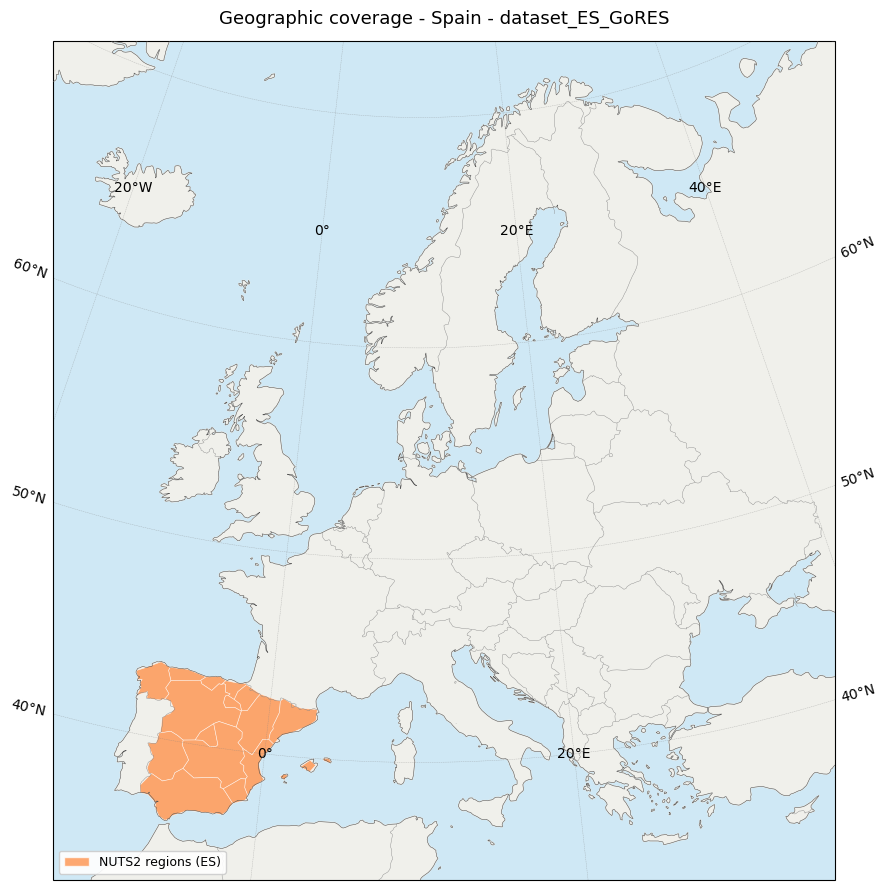

In [8]:
# Plot: map of areas included in the selected focus region
# - Selected countries are shown at NUTS2 resolution when geometry is available
# - If NUTS2 geometry is missing for a selected country, its NUTS0 geometry is used when available
# - Offshore nodes are shown as triangle markers

with BASEMAP_FILE.open("r", encoding="utf-8") as _f:
    _geo_data = json.load(_f)

_available_nuts2_codes = available_nuts2_country_codes(_geo_data)
_missing_nuts2 = missing_focus_nuts2_countries(_available_nuts2_codes)
_focus_geojson_codes = set(NUTS2_COUNTRIES)
_nuts2_geojson_codes = _focus_geojson_codes.intersection(_available_nuts2_codes)

_nuts2_polys = []
_nuts0_polys = []

for _feat in _geo_data["features"]:
    _props = _feat.get("properties", {})
    _geom  = _feat.get("geometry")
    if not _geom:
        continue
    _cntr = str(_props.get("CNTR_CODE", "")).strip().upper()
    try:
        _level = int(_props.get("LEVL_CODE"))
    except (TypeError, ValueError):
        continue
    if _cntr not in _focus_geojson_codes:
        continue
    if _cntr in _nuts2_geojson_codes and _level == 2:
        _nuts2_polys.append(shape(_geom))
    elif _cntr not in _nuts2_geojson_codes and _level == 0:
        _nuts0_polys.append(shape(_geom))

# Offshore node coordinates
_offshore_df = coords[coords["norm_node"].isin(offshore_norm_nodes)].copy()

fig, ax = plt.subplots(
    figsize=(13, 9),
    subplot_kw={"projection": ccrs.LambertConformal(central_longitude=10, central_latitude=52)},
)
ax.set_extent([-12, 35, 34, 72], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.OCEAN,    color="#cfe8f5", zorder=0)
ax.add_feature(cfeature.LAND,     color="#f0f0eb", zorder=0)

# Country-level polygons used only as fallback where NUTS2 geometry is unavailable
if _nuts0_polys:
    ax.add_geometries(
        _nuts0_polys, crs=GEOJSON_SOURCE_CRS,
        facecolor="#4da6ff", edgecolor="white", linewidth=0.6, alpha=0.75, zorder=1,
    )

# NUTS2 polygons
if _nuts2_polys:
    ax.add_geometries(
        _nuts2_polys, crs=GEOJSON_SOURCE_CRS,
        facecolor="#ff8c42", edgecolor="white", linewidth=0.4, alpha=0.75, zorder=2,
    )

# Offshore nodes
if not _offshore_df.empty:
    ax.scatter(
        _offshore_df["Longitude"].values, _offshore_df["Latitude"].values,
        transform=ccrs.PlateCarree(),
        s=50, color="#1a7a3e", marker="^", zorder=4, label="Offshore node",
    )
    for _, _row in _offshore_df.iterrows():
        ax.text(
            _row["Longitude"], _row["Latitude"] + 0.4, _row["Location"],
            transform=ccrs.PlateCarree(),
            fontsize=5.5, ha="center", va="bottom", color="#1a7a3e", zorder=5,
        )

ax.add_feature(cfeature.BORDERS, linestyle="-", linewidth=0.3, edgecolor="#888888", zorder=3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="#555555", zorder=3)
ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5, linestyle="--")

_nuts2_label = f"NUTS2 regions ({FOCUSED_COUNTRY_LABEL})"
_legend = [
    Patch(facecolor="#ff8c42", edgecolor="white", alpha=0.75, label=_nuts2_label),
]
if _nuts0_polys:
    _legend.append(
        Patch(facecolor="#4da6ff", edgecolor="white", alpha=0.75, label="Selected country without NUTS2 geometry"),
    )
if not _offshore_df.empty:
    _legend.append(
        Line2D([0], [0], marker="^", color="w", markerfacecolor="#1a7a3e",
               markersize=8, label="Offshore node"),
    )
ax.legend(handles=_legend, loc="lower left", fontsize=9, framealpha=0.9)
ax.set_title(f"Geographic coverage - {FOCUSED_AREA} - {DATASET_NAME}", fontsize=13, pad=12)
if _missing_nuts2:
    print(
        "No NUTS2 geometry found in "
        f"{BASEMAP_FILE.name} for: {', '.join(_missing_nuts2)}"
    )
plt.tight_layout()
plt.show()


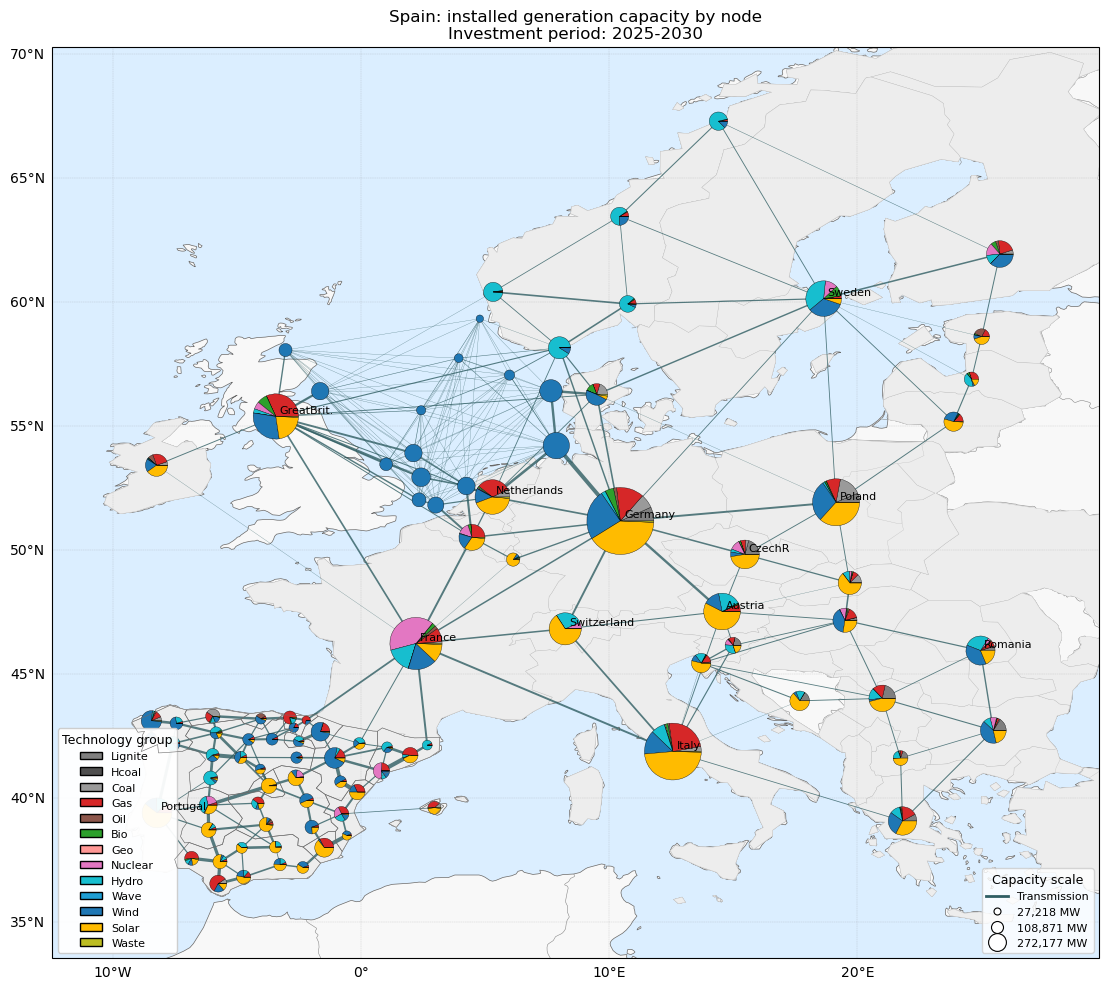

Period 2025-2030: 95 nodes plotted.


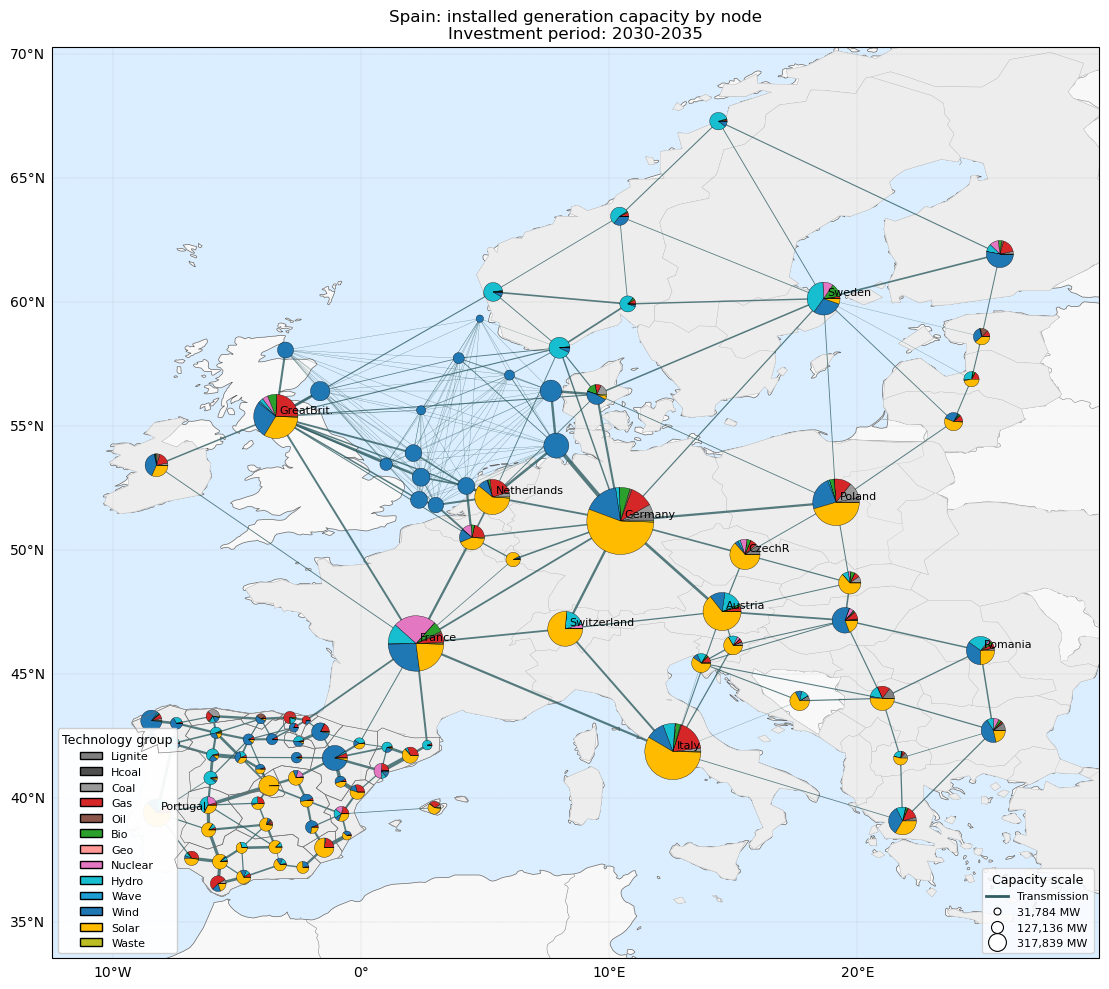

Period 2030-2035: 95 nodes plotted.


In [9]:
# ── Plot: installed capacity pies (one figure per period) ─
coord_lookup = coords[["norm_node", "Latitude", "Longitude"]].drop_duplicates("norm_node")

for period in periods:
    if period not in capacity_by_period:
        print(f"Period {period}: no generation data, skipping.")
        continue

    capacity = capacity_by_period[period]
    if AGGREGATE_OFFSHORE_TO_CLOSEST_ONSHORE:
        capacity = aggregate_offshore_to_nearest_onshore(capacity, coords, offshore_norm_nodes, offshore_to_onshore)

    merged = capacity.merge(coord_lookup, on="norm_node", how="left")
    n_missing = merged["Latitude"].isna().sum()
    if n_missing:
        print(f"Period {period}: {n_missing} nodes without coordinates skipped:", merged.loc[merged["Latitude"].isna(), "Node"].tolist())
    merged = merged.dropna(subset=["Latitude", "Longitude"]).copy()
    if merged.empty:
        continue

    lines = transmission_by_period.get(period, pd.DataFrame(columns=["u", "v", "transmissionInstalledCap"])).copy()
    if not lines.empty and AGGREGATE_OFFSHORE_TO_CLOSEST_ONSHORE:
        lines["u"] = lines["u"].map(offshore_to_onshore).fillna(lines["u"])
        lines["v"] = lines["v"].map(offshore_to_onshore).fillna(lines["v"])
        lines = lines[lines["u"] != lines["v"]].copy()
        lines["a"] = np.where(lines["u"] <= lines["v"], lines["u"], lines["v"])
        lines["b"] = np.where(lines["u"] <= lines["v"], lines["v"], lines["u"])
        lines = lines.groupby(["a", "b"], as_index=False)["transmissionInstalledCap"].sum()
        lines = lines.rename(columns={"a": "u", "b": "v"})
    lines = (
        lines.merge(coord_lookup, left_on="u", right_on="norm_node", how="left")
        .rename(columns={"Latitude": "from_lat", "Longitude": "from_lon"}).drop(columns=["norm_node"])
        .merge(coord_lookup, left_on="v", right_on="norm_node", how="left")
        .rename(columns={"Latitude": "to_lat", "Longitude": "to_lon"}).drop(columns=["norm_node"])
    )
    lines = lines.dropna(subset=["from_lat", "from_lon", "to_lat", "to_lon"]).copy()

    # ── draw ──────────────────────────────────────────────
    projection = ccrs.PlateCarree()
    fig, ax = plt.subplots(figsize=(14, 10), subplot_kw={"projection": projection})
    ax.add_feature(cfeature.OCEAN, facecolor="#dbeeff", zorder=0)
    ax.add_feature(cfeature.LAND, facecolor="#f8f8f8", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="#666666", zorder=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor="#888888", zorder=1)
    if BASEMAP_FILE.exists():
        ax.add_geometries(load_geojson_geometries(BASEMAP_FILE), crs=GEOJSON_SOURCE_CRS,
                          facecolor="#ededed", edgecolor="#b6b6b6", linewidth=0.2, zorder=1)
        nuts2_borders = load_nuts2_country_borders(BASEMAP_FILE, NUTS2_COUNTRIES)
        if nuts2_borders:
            ax.add_geometries(nuts2_borders, crs=GEOJSON_SOURCE_CRS, facecolor="none", edgecolor="#6B6B6B", linewidth=0.4, zorder=6)

    cap_vals = merged["total_cap"].clip(lower=0)
    max_cap  = cap_vals.max() if len(cap_vals) else 0.0
    radii = 0.15 + 1.2 * np.sqrt(cap_vals / max_cap) if max_cap > 0 else np.full(len(merged), 0.15)

    if not lines.empty:
        max_lc = float(lines["transmissionInstalledCap"].max())
        for _, line in lines.iterrows():
            lw = 0.2 + 2.8 * np.sqrt(float(line["transmissionInstalledCap"]) / max_lc) if max_lc > 0 else 0.2
            ax.plot([line["from_lon"], line["to_lon"]], [line["from_lat"], line["to_lat"]],
                    color="#2F5D62", linewidth=lw, alpha=0.8, transform=projection, zorder=4)

    for (_, row), radius in zip(merged.iterrows(), radii):
        total = float(row["total_cap"])
        if total <= 0:
            continue
        theta1 = 0.0
        for tech in TECH_ORDER:
            val = float(row[tech])
            if val <= 0:
                continue
            theta2 = theta1 + (val / total) * 360.0
            ax.add_patch(Wedge((row["Longitude"], row["Latitude"]), float(radius),
                               float(theta1), float(theta2),
                               facecolor=TECH_COLORS[tech], edgecolor="black", linewidth=0.25,
                               transform=projection, zorder=5))
            theta1 = theta2

    for _, row in merged.nlargest(12, "total_cap").iterrows():
        ax.text(row["Longitude"] + 0.15, row["Latitude"] + 0.15, row["Node"],
                fontsize=8, transform=projection, zorder=6)

    ax.set_extent([merged["Longitude"].min()-4, merged["Longitude"].max()+4,
                   merged["Latitude"].min()-3,  merged["Latitude"].max()+3], crs=projection)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.4, linestyle="--", zorder=2)
    gl.top_labels = False; gl.right_labels = False
    ax.set_title(f"{FOCUSED_AREA}: installed generation capacity by node\nInvestment period: {period}")

    tech_legend = [Patch(facecolor=TECH_COLORS[t], edgecolor="black", label=t) for t in TECH_ORDER]
    leg1 = ax.legend(handles=tech_legend, loc="lower left", fontsize=8, title="Technology group", title_fontsize=9, framealpha=0.95)
    ax.add_artist(leg1)
    if max_cap > 0:
        size_vals = [max_cap * f for f in [0.1, 0.4, 1.0]]
        size_handles = [Line2D([0],[0], marker="o", color="none", markerfacecolor="white",
                                markeredgecolor="black", markeredgewidth=0.8,
                                markersize=(0.15+1.2*np.sqrt(v/max_cap))*9.5, label=f"{v:,.0f} MW")
                        for v in size_vals]
        ax.legend(handles=[Line2D([0],[0], color="#2F5D62", lw=2, label="Transmission"), *size_handles],
                  loc="lower right", title="Capacity scale", title_fontsize=9, fontsize=8)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f'gen_capacity_{period}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Period {period}: {len(merged)} nodes plotted.")


Technologies by change group:
  renewable_generation: ['Bio', 'BioCCS', 'Geo', 'Hydroregulated', 'Hydrorun-of-the-river', 'Solar', 'Waste', 'Wave', 'Windoffshorefloating', 'Windoffshoregrounded', 'Windonshore']
  thermal_generation_including_nuclear: ['Coal', 'CoalCCS', 'GasCCGT', 'GasCCS', 'GasOCGT', 'Lignite', 'LigniteCCS', 'Nuclear', 'Oil']
  coal: ['Coal', 'CoalCCS', 'Lignite', 'LigniteCCS']
  wind_and_solar: ['Solar', 'Windoffshorefloating', 'Windoffshoregrounded', 'Windonshore']
  hydro: ['Hydroregulated', 'Hydrorun-of-the-river']


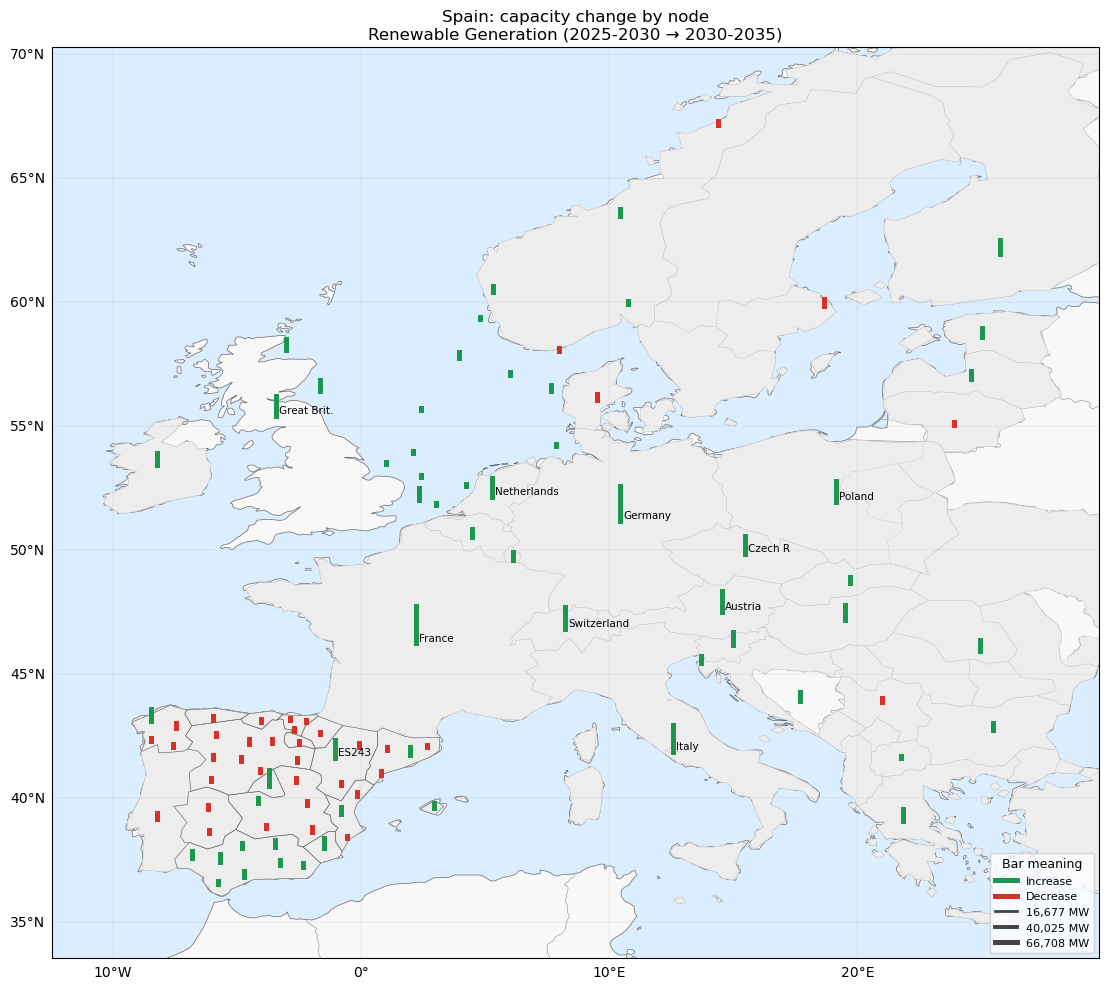

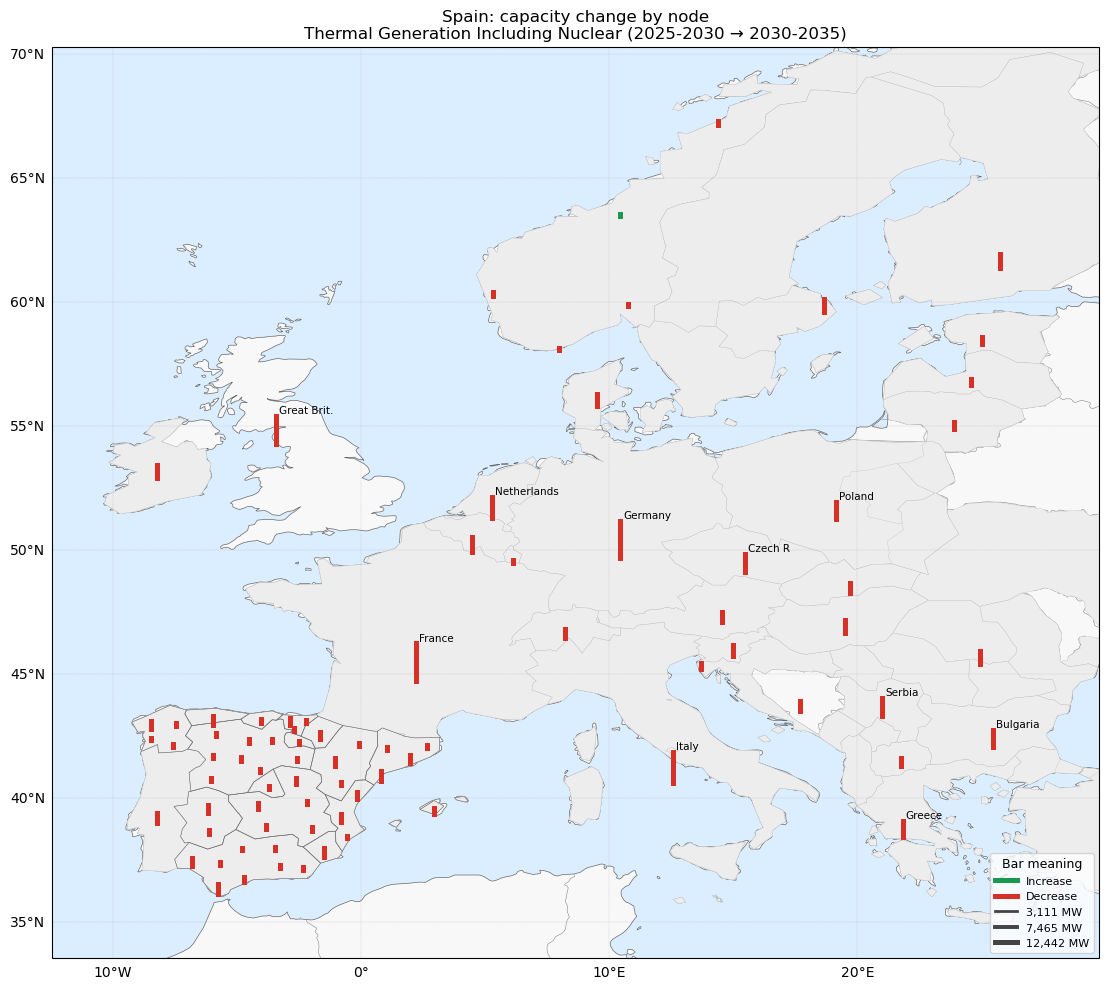

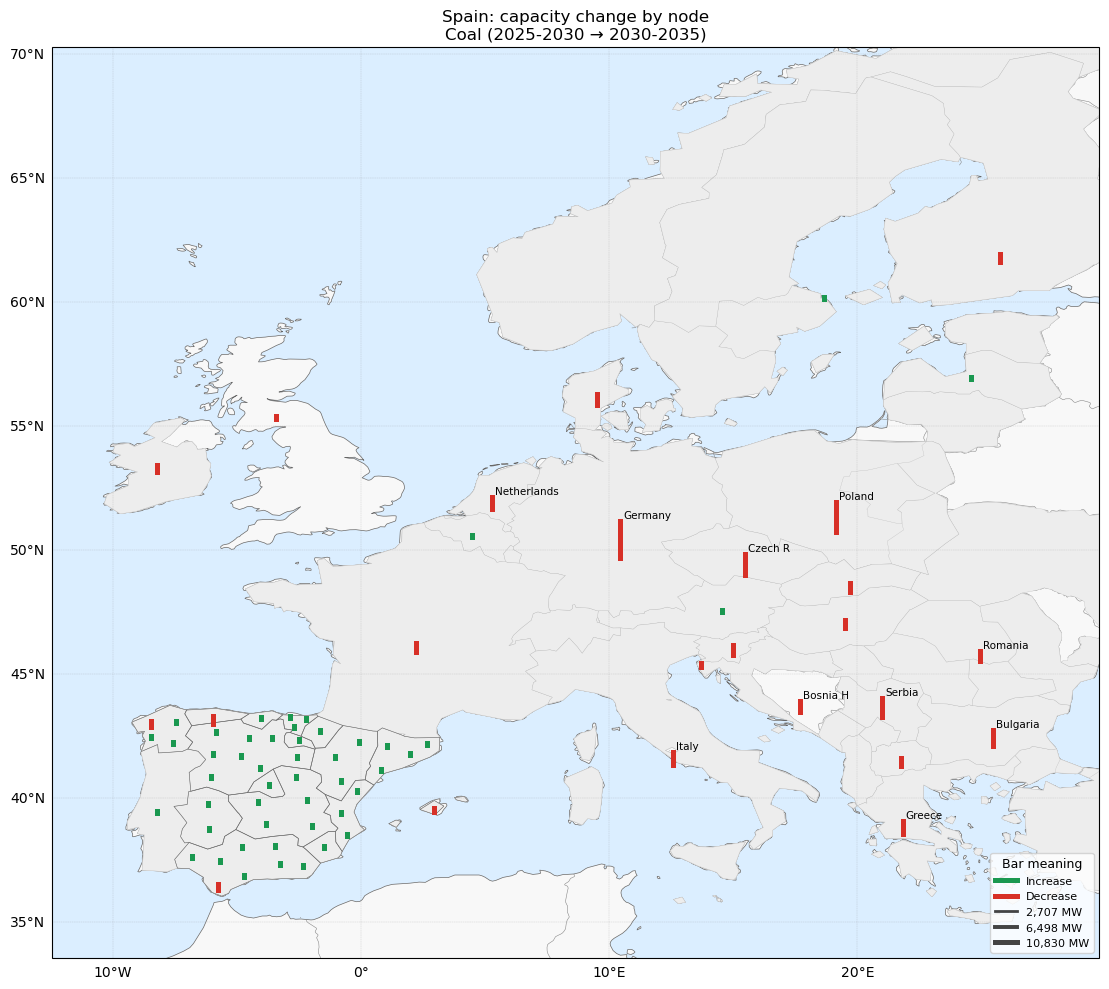

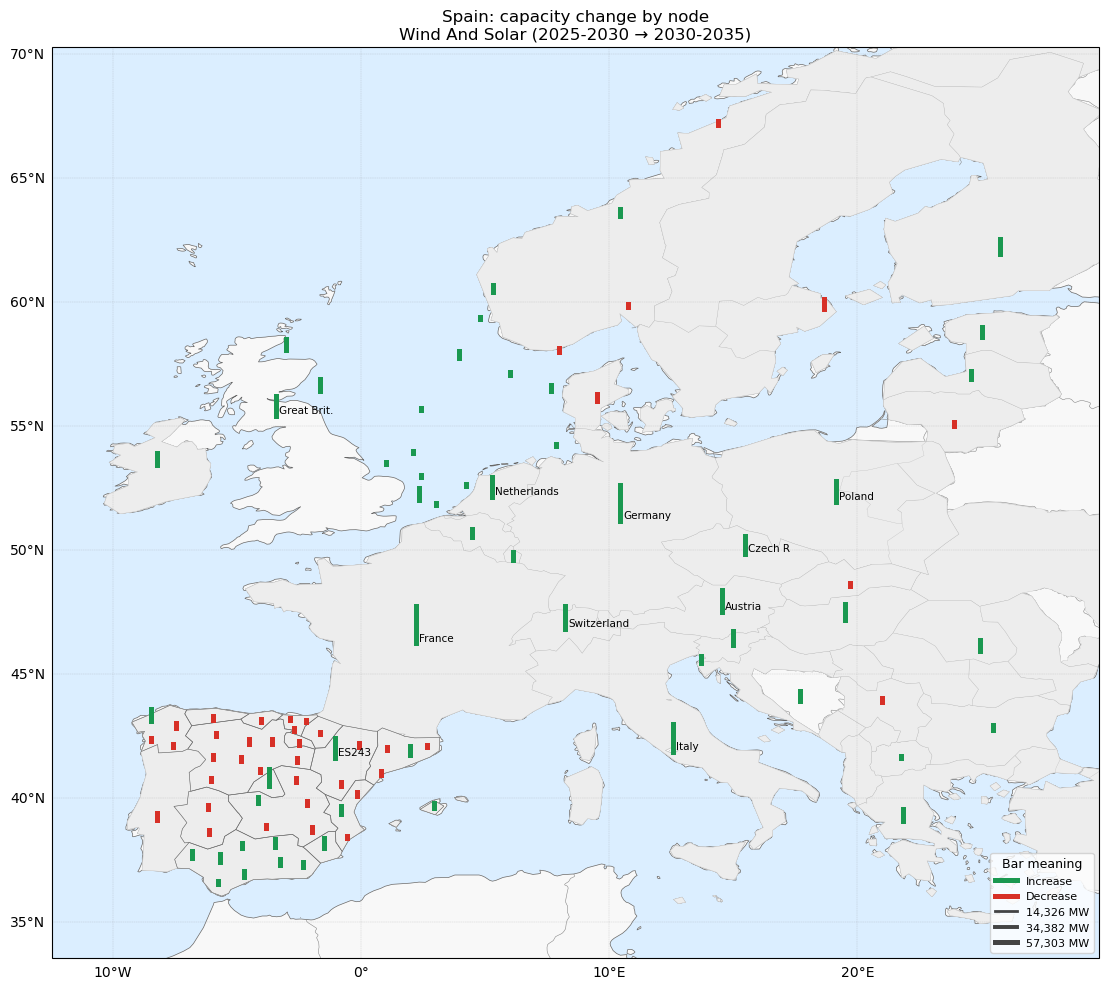

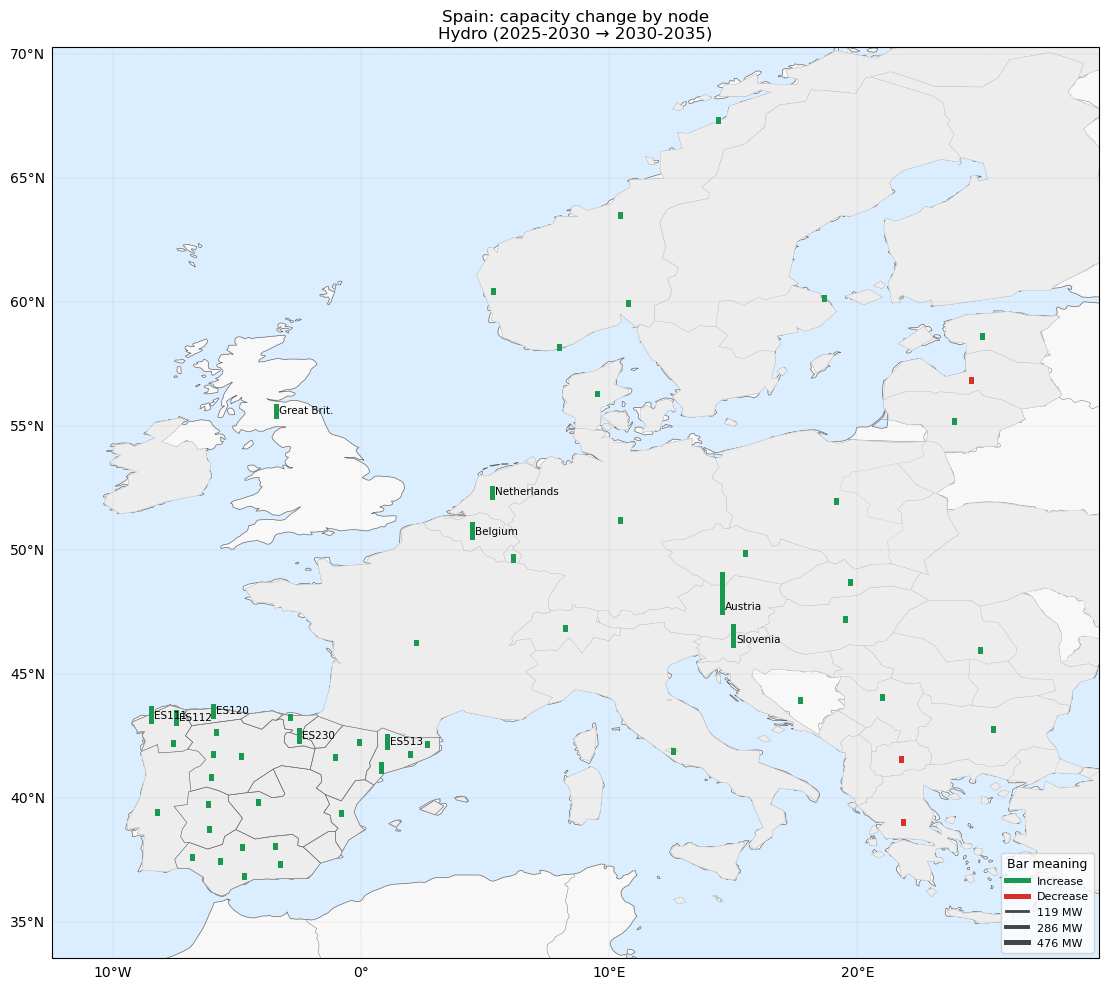

In [10]:
# ── Plot: installed-capacity change bars (first → last period) ─
period_first = gen_periods[0]
period_last  = gen_periods[-1]

# Print which actual generator types in the dataset fall into each change group
_gen_raw = pd.read_csv(RESULTS_PATH / 'Output' / 'results_output_gen.csv')
_gen_raw['TechGroup'] = _gen_raw['GeneratorType'].map(map_generator_to_group)
print('Technologies by change group:')
for _gname, _gtechs in CHANGE_GROUPS.items():
    _matched = sorted(_gen_raw.loc[_gen_raw['TechGroup'].isin(_gtechs), 'GeneratorType'].unique())
    print(f'  {_gname}: {_matched}')

if period_first in capacity_by_period and period_last in capacity_by_period:
    cap_first = capacity_by_period[period_first]
    cap_last  = capacity_by_period[period_last]
    if AGGREGATE_OFFSHORE_TO_CLOSEST_ONSHORE:
        cap_first = aggregate_offshore_to_nearest_onshore(cap_first, coords, offshore_norm_nodes, offshore_to_onshore)
        cap_last  = aggregate_offshore_to_nearest_onshore(cap_last,  coords, offshore_norm_nodes, offshore_to_onshore)

    for group_label, techs in CHANGE_GROUPS.items():
        delta_df = build_change_dataframe(cap_first, cap_last, techs)
        plot_df = (
            delta_df.merge(coords[["norm_node", "Location", "Latitude", "Longitude"]], on="norm_node", how="left")
            .dropna(subset=["Latitude", "Longitude"]).copy()
        )
        if plot_df.empty:
            print(f"No coordinates for group '{group_label}', skipping.")
            continue

        max_abs = float(plot_df["delta_mw"].abs().max()) or 1.0
        min_h, max_h = 0.08, 1.5

        projection = ccrs.PlateCarree()
        fig, ax = plt.subplots(figsize=(14, 10), subplot_kw={"projection": projection})
        ax.add_feature(cfeature.OCEAN, facecolor="#dbeeff", zorder=0)
        ax.add_feature(cfeature.LAND, facecolor="#f8f8f8", zorder=0)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="#666666", zorder=1)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor="#888888", zorder=1)
        if BASEMAP_FILE.exists():
            ax.add_geometries(load_geojson_geometries(BASEMAP_FILE), crs=GEOJSON_SOURCE_CRS,
                              facecolor="#ededed", edgecolor="#b6b6b6", linewidth=0.2, zorder=1)
            nuts2_borders = load_nuts2_country_borders(BASEMAP_FILE, NUTS2_COUNTRIES)
            if nuts2_borders:
                ax.add_geometries(nuts2_borders, crs=GEOJSON_SOURCE_CRS, facecolor="none",
                                  edgecolor="#6B6B6B", linewidth=0.4, zorder=3)

        for _, row in plot_df.iterrows():
            delta = float(row["delta_mw"])
            if abs(delta) < 1e-9:
                continue
            bar_h = min_h + (max_h - min_h) * np.sqrt(abs(delta) / max_abs)
            y0 = float(row["Latitude"])
            ax.plot([row["Longitude"], row["Longitude"]], [y0, y0 + (bar_h if delta > 0 else -bar_h)],
                    color="#1a9850" if delta > 0 else "#d73027",
                    linewidth=3.6, transform=projection, zorder=4)

        for _, row in plot_df.loc[plot_df["delta_mw"].abs().nlargest(10).index].iterrows():
            ax.text(row["Longitude"]+0.12, row["Latitude"]+0.12, str(row["Location"]),
                    fontsize=7.5, transform=projection, zorder=5)

        ax.set_extent([plot_df["Longitude"].min()-4, plot_df["Longitude"].max()+4,
                       plot_df["Latitude"].min()-3,  plot_df["Latitude"].max()+3], crs=projection)
        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.4, linestyle="--", zorder=2)
        gl.top_labels = False; gl.right_labels = False
        ax.set_title(f"{FOCUSED_AREA}: capacity change by node\n{group_label.replace('_',' ').title()} ({period_first} → {period_last})")

        size_vals = [0.25*max_abs, 0.6*max_abs, max_abs]
        legend_handles = [
            Line2D([0],[0], color="#1a9850", lw=3.6, label="Increase"),
            Line2D([0],[0], color="#d73027", lw=3.6, label="Decrease"),
            *[Line2D([0],[0], color="#444", lw=max(2.0, 3.6*(min_h+(max_h-min_h)*np.sqrt(v/max_abs))/max_h),
                     label=f"{v:,.0f} MW") for v in size_vals],
        ]
        ax.legend(handles=legend_handles, loc="lower right", title="Bar meaning", title_fontsize=9, fontsize=8)
        plt.tight_layout()
        plt.savefig(PLOT_DIR / f'capacity_change_{group_label}.png', dpi=150, bbox_inches='tight')
        plt.show()


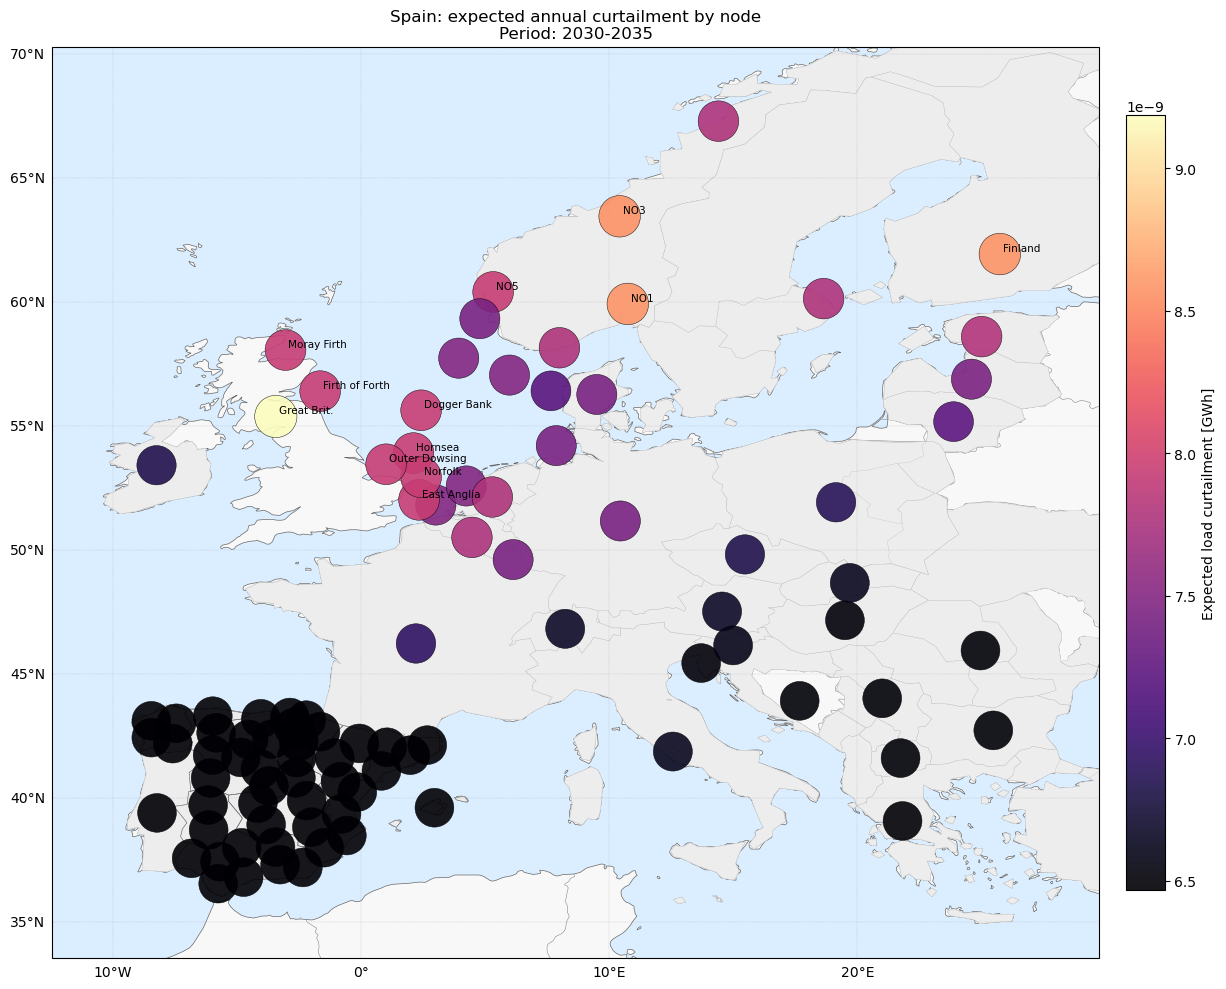

In [11]:
# ── Plot: expected load curtailment (last period) ─────────
curtailment, curtail_period = load_load_curtailment_last_period(RESULTS_PATH)

if AGGREGATE_OFFSHORE_TO_CLOSEST_ONSHORE and not curtailment.empty:
    curtailment["target_norm_node"] = curtailment["norm_node"].map(offshore_to_onshore).fillna(curtailment["norm_node"])
    curtailment = (
        curtailment.groupby("target_norm_node", as_index=False)["ExpectedLoadCurtailment_GWh"]
        .sum().rename(columns={"target_norm_node": "norm_node"})
    )

plot_df = (
    curtailment.merge(coords[["norm_node", "Location", "Latitude", "Longitude"]], on="norm_node", how="left")
    .dropna(subset=["Latitude", "Longitude"]).copy()
 )

values = plot_df["ExpectedLoadCurtailment_GWh"].clip(lower=0.0)
vmax   = float(values.max()) if len(values) else 0.0
sizes  = 25 + 900 * np.sqrt(values / vmax) if vmax > 0 else np.full(len(plot_df), 25.0)

projection = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(14, 10), subplot_kw={"projection": projection})
ax.add_feature(cfeature.OCEAN, facecolor="#dbeeff", zorder=0)
ax.add_feature(cfeature.LAND, facecolor="#f8f8f8", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="#666666", zorder=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor="#888888", zorder=1)
if BASEMAP_FILE.exists():
    ax.add_geometries(load_geojson_geometries(BASEMAP_FILE), crs=GEOJSON_SOURCE_CRS,
                      facecolor="#ededed", edgecolor="#b6b6b6", linewidth=0.2, zorder=1)
    nuts2_borders = load_nuts2_country_borders(BASEMAP_FILE, NUTS2_COUNTRIES)
    if nuts2_borders:
        ax.add_geometries(nuts2_borders, crs=GEOJSON_SOURCE_CRS, facecolor="none",
                          edgecolor="#6B6B6B", linewidth=0.4, zorder=3)

sc = ax.scatter(plot_df["Longitude"], plot_df["Latitude"],
                s=sizes, c=values, cmap="magma", alpha=0.9,
                edgecolor="black", linewidth=0.35, transform=projection, zorder=5)
for _, row in plot_df.nlargest(12, "ExpectedLoadCurtailment_GWh").iterrows():
    ax.text(row["Longitude"]+0.12, row["Latitude"]+0.12, str(row["Location"]),
            fontsize=7.5, transform=projection, zorder=6)

ax.set_extent([plot_df["Longitude"].min()-4, plot_df["Longitude"].max()+4,
               plot_df["Latitude"].min()-3,  plot_df["Latitude"].max()+3], crs=projection)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.4, linestyle="--", zorder=2)
gl.top_labels = False; gl.right_labels = False
ax.set_title(f"{FOCUSED_AREA}: expected annual curtailment by node\nPeriod: {curtail_period}")
cbar = plt.colorbar(sc, ax=ax, shrink=0.85, pad=0.02)
cbar.set_label("Expected load curtailment [GWh]")
plt.tight_layout()
plt.savefig(PLOT_DIR / f'load_curtailment_{curtail_period}.png', dpi=150, bbox_inches='tight')
plt.show()


Transmission change: 2025-2030 → 2030-2035
Links with capacity change: 150


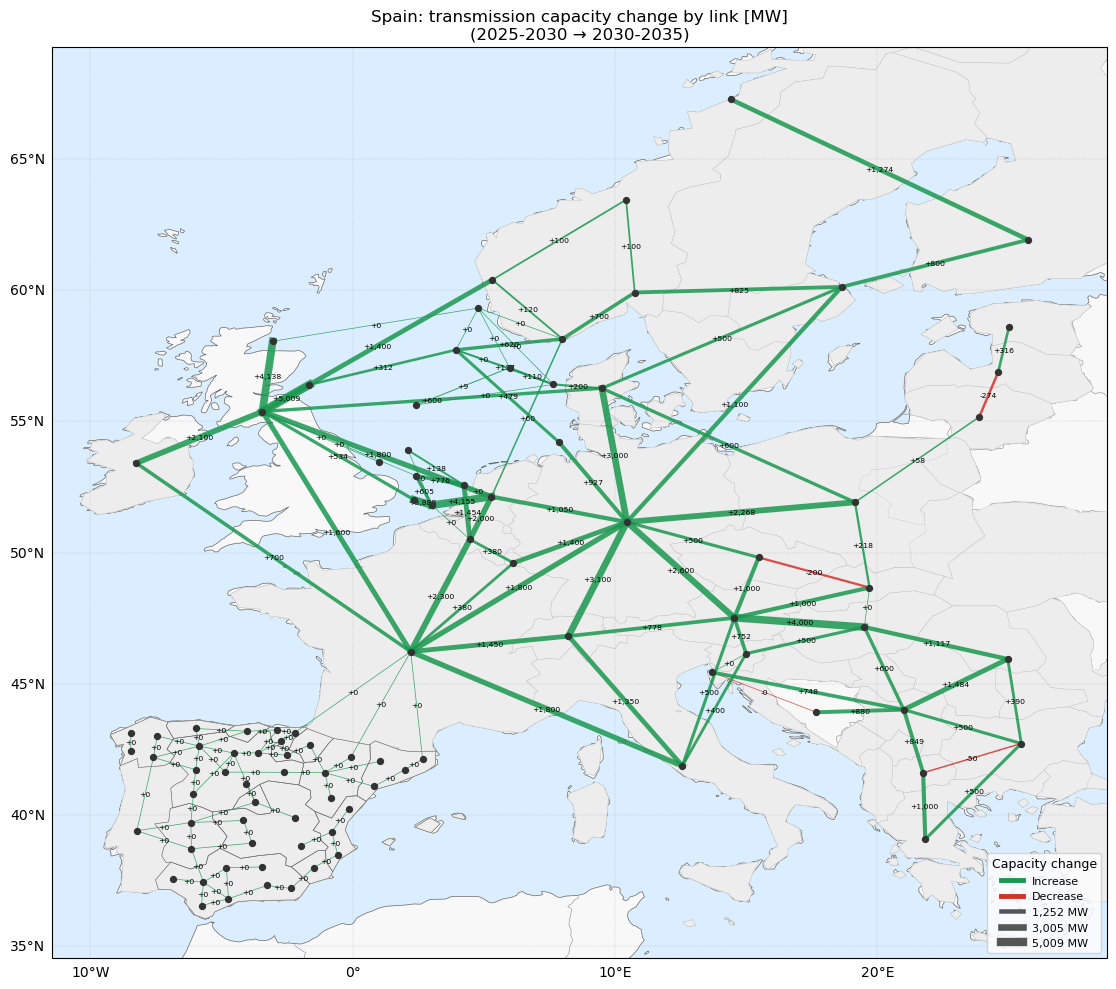

In [12]:
# ── Plot: transmission capacity change (first → last period) ─
# Load raw transmission CSV to compute per-link delta
_trans_raw = pd.read_csv(RESULTS_PATH / 'Output' / 'results_output_transmision.csv')
_trans_raw['transmissionInstalledCap_MW'] = pd.to_numeric(
    _trans_raw['transmissionInstalledCap_MW'], errors='coerce').fillna(0.0)
_trans_raw['Period'] = _trans_raw['Period'].astype(str)
if YEAR_SHIFT:
    _trans_raw['Period'] = _trans_raw['Period'].map(lambda x: shift_period_label(x, YEAR_SHIFT))
_trans_raw['u'] = _trans_raw.apply(
    lambda r: normalize_name(r['BetweenNode']) if normalize_name(r['BetweenNode']) <= normalize_name(r['AndNode'])
              else normalize_name(r['AndNode']), axis=1)
_trans_raw['v'] = _trans_raw.apply(
    lambda r: normalize_name(r['AndNode']) if normalize_name(r['BetweenNode']) <= normalize_name(r['AndNode'])
              else normalize_name(r['BetweenNode']), axis=1)

# Deduplicate to max cap per link per period
_trans_raw = _trans_raw.groupby(['Period', 'u', 'v'], as_index=False)['transmissionInstalledCap_MW'].max()

_t_first = line_periods[0]
_t_last  = line_periods[-1]
print(f"Transmission change: {_t_first} → {_t_last}")

_first_links = _trans_raw.loc[_trans_raw['Period'] == _t_first, ['u', 'v', 'transmissionInstalledCap_MW']].rename(
    columns={'transmissionInstalledCap_MW': 'cap_first'})
_last_links  = _trans_raw.loc[_trans_raw['Period'] == _t_last,  ['u', 'v', 'transmissionInstalledCap_MW']].rename(
    columns={'transmissionInstalledCap_MW': 'cap_last'})

_delta_links = (
    _first_links.merge(_last_links, on=['u', 'v'], how='outer').fillna(0.0)
)
_delta_links['delta_MW'] = _delta_links['cap_last'] - _delta_links['cap_first']
_delta_links = _delta_links[_delta_links['delta_MW'].abs() > 1e-6].copy()

# Attach coordinates for both endpoints
_coord_lu = coords[['norm_node', 'Latitude', 'Longitude']].drop_duplicates('norm_node')
_delta_links = (
    _delta_links
    .merge(_coord_lu, left_on='u', right_on='norm_node', how='left')
    .rename(columns={'Latitude': 'lat_u', 'Longitude': 'lon_u'}).drop(columns=['norm_node'])
    .merge(_coord_lu, left_on='v', right_on='norm_node', how='left')
    .rename(columns={'Latitude': 'lat_v', 'Longitude': 'lon_v'}).drop(columns=['norm_node'])
    .dropna(subset=['lat_u', 'lon_u', 'lat_v', 'lon_v'])
)
print(f"Links with capacity change: {len(_delta_links)}")

if not _delta_links.empty:
    max_abs_trans = float(_delta_links['delta_MW'].abs().max())
    min_lw, max_lw = 0.5, 6.0

    projection = ccrs.PlateCarree()
    fig, ax = plt.subplots(figsize=(14, 10), subplot_kw={'projection': projection})
    ax.add_feature(cfeature.OCEAN,     facecolor='#dbeeff', zorder=0)
    ax.add_feature(cfeature.LAND,      facecolor='#f8f8f8', zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='#666666', zorder=1)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.4, edgecolor='#888888', zorder=1)
    if BASEMAP_FILE.exists():
        ax.add_geometries(load_geojson_geometries(BASEMAP_FILE), crs=GEOJSON_SOURCE_CRS,
                          facecolor='#ededed', edgecolor='#b6b6b6', linewidth=0.2, zorder=1)
        nuts2_borders = load_nuts2_country_borders(BASEMAP_FILE, NUTS2_COUNTRIES)
        if nuts2_borders:
            ax.add_geometries(nuts2_borders, crs=GEOJSON_SOURCE_CRS, facecolor='none',
                              edgecolor='#6B6B6B', linewidth=0.4, zorder=3)

    for _, lnk in _delta_links.iterrows():
        d = float(lnk['delta_MW'])
        lw = min_lw + (max_lw - min_lw) * np.sqrt(abs(d) / max_abs_trans)
        color = '#1a9850' if d > 0 else '#d73027'
        mid_lon = (lnk['lon_u'] + lnk['lon_v']) / 2
        mid_lat = (lnk['lat_u'] + lnk['lat_v']) / 2
        ax.plot([lnk['lon_u'], lnk['lon_v']], [lnk['lat_u'], lnk['lat_v']],
                color=color, linewidth=lw, alpha=0.85, transform=projection, zorder=4)
        ax.text(mid_lon, mid_lat, f"{d:+,.0f}", fontsize=5.5, ha='center', va='center',
                color='black', transform=projection, zorder=5)

    # Plot all nodes as small dots for reference
    all_nodes = pd.concat([
        _delta_links[['u', 'lat_u', 'lon_u']].rename(columns={'u': 'norm_node', 'lat_u': 'Latitude', 'lon_u': 'Longitude'}),
        _delta_links[['v', 'lat_v', 'lon_v']].rename(columns={'v': 'norm_node', 'lat_v': 'Latitude', 'lon_v': 'Longitude'}),
    ]).drop_duplicates('norm_node')
    ax.scatter(all_nodes['Longitude'], all_nodes['Latitude'], s=18, color='#333333',
               zorder=6, transform=projection)

    all_lons = pd.concat([_delta_links['lon_u'], _delta_links['lon_v']])
    all_lats = pd.concat([_delta_links['lat_u'], _delta_links['lat_v']])
    ax.set_extent([all_lons.min()-3, all_lons.max()+3, all_lats.min()-2, all_lats.max()+2], crs=projection)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.4, linestyle='--', zorder=2)
    gl.top_labels = False; gl.right_labels = False
    ax.set_title(f"{FOCUSED_AREA}: transmission capacity change by link [MW]\n({_t_first} → {_t_last})")

    size_vals_t = [0.25*max_abs_trans, 0.6*max_abs_trans, max_abs_trans]
    legend_handles_t = [
        Line2D([0],[0], color='#1a9850', lw=3.5, label='Increase'),
        Line2D([0],[0], color='#d73027', lw=3.5, label='Decrease'),
        *[Line2D([0],[0], color='#555',
                 lw=min_lw+(max_lw-min_lw)*np.sqrt(v/max_abs_trans),
                 label=f'{v:,.0f} MW') for v in size_vals_t],
    ]
    ax.legend(handles=legend_handles_t, loc='lower right', title='Capacity change', title_fontsize=9, fontsize=8)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / 'transmission_capacity_change.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No transmission links with capacity change found between the two periods.")


Transmission % change: 2025-2030 → 2030-2035
Links with capacity change: 150


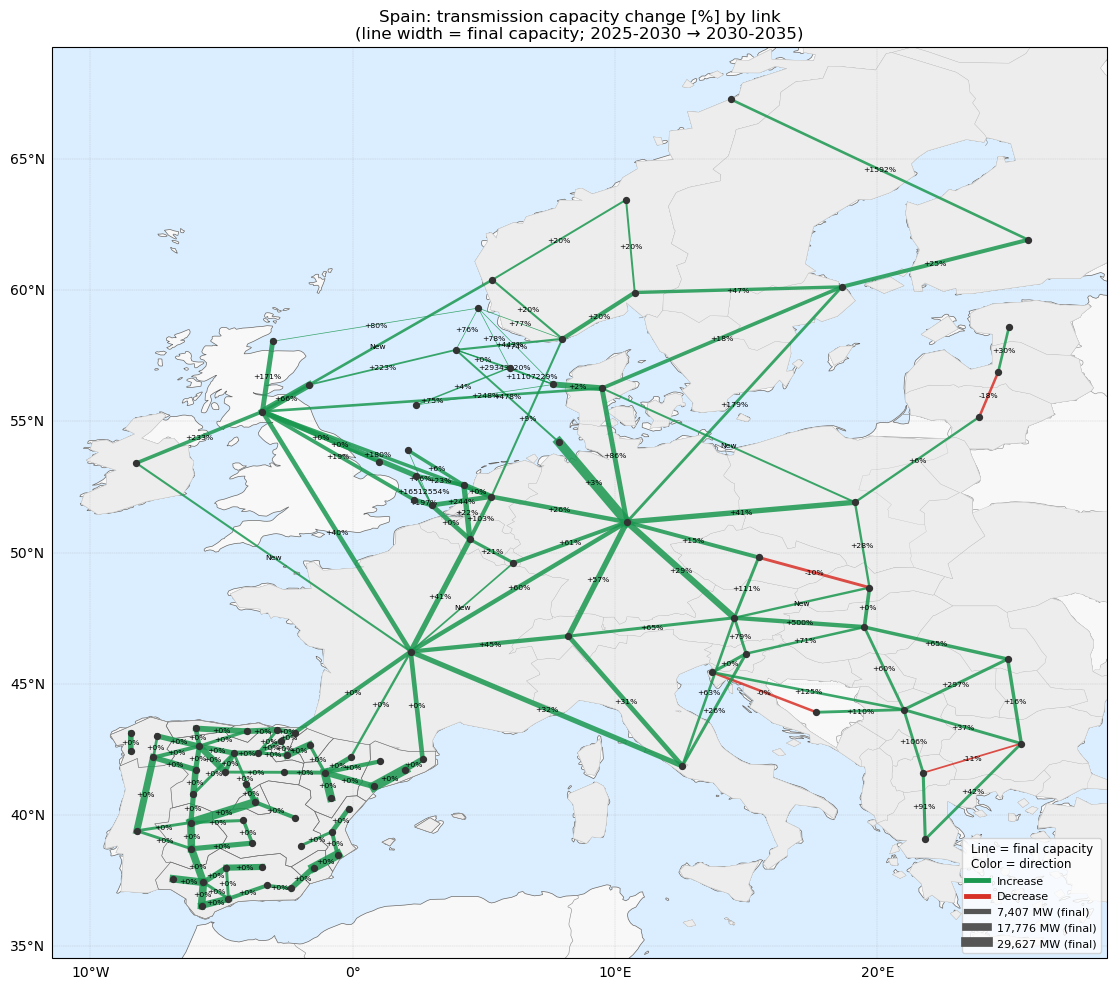

In [13]:
# ── Plot: transmission capacity change – percentage labels, width = final capacity ──
_trans2 = pd.read_csv(RESULTS_PATH / 'Output' / 'results_output_transmision.csv')
_trans2['transmissionInstalledCap_MW'] = pd.to_numeric(
    _trans2['transmissionInstalledCap_MW'], errors='coerce').fillna(0.0)
_trans2['Period'] = _trans2['Period'].astype(str)
if YEAR_SHIFT:
    _trans2['Period'] = _trans2['Period'].map(lambda x: shift_period_label(x, YEAR_SHIFT))
_trans2['u'] = _trans2.apply(
    lambda r: normalize_name(r['BetweenNode']) if normalize_name(r['BetweenNode']) <= normalize_name(r['AndNode'])
              else normalize_name(r['AndNode']), axis=1)
_trans2['v'] = _trans2.apply(
    lambda r: normalize_name(r['AndNode']) if normalize_name(r['BetweenNode']) <= normalize_name(r['AndNode'])
              else normalize_name(r['BetweenNode']), axis=1)
_trans2 = _trans2.groupby(['Period', 'u', 'v'], as_index=False)['transmissionInstalledCap_MW'].max()

_t2_first = line_periods[0]
_t2_last  = line_periods[-1]
print(f"Transmission % change: {_t2_first} → {_t2_last}")

_f2 = _trans2.loc[_trans2['Period'] == _t2_first, ['u', 'v', 'transmissionInstalledCap_MW']].rename(
    columns={'transmissionInstalledCap_MW': 'cap_first'})
_l2 = _trans2.loc[_trans2['Period'] == _t2_last,  ['u', 'v', 'transmissionInstalledCap_MW']].rename(
    columns={'transmissionInstalledCap_MW': 'cap_last'})

_dl2 = _f2.merge(_l2, on=['u', 'v'], how='outer').fillna(0.0)
_dl2['delta_MW']  = _dl2['cap_last'] - _dl2['cap_first']
_dl2 = _dl2[_dl2['delta_MW'].abs() > 1e-6].copy()

# Percentage change label
def _pct_label(row):
    if row['cap_first'] < 1e-6:
        return 'New'
    if row['cap_last'] < 1e-6:
        return '-100%'
    pct = row['delta_MW'] / row['cap_first'] * 100.0
    return f"{pct:+.0f}%"

_dl2['pct_label'] = _dl2.apply(_pct_label, axis=1)

# Attach coordinates
_coord_lu2 = coords[['norm_node', 'Latitude', 'Longitude']].drop_duplicates('norm_node')
_dl2 = (
    _dl2
    .merge(_coord_lu2, left_on='u', right_on='norm_node', how='left')
    .rename(columns={'Latitude': 'lat_u', 'Longitude': 'lon_u'}).drop(columns=['norm_node'])
    .merge(_coord_lu2, left_on='v', right_on='norm_node', how='left')
    .rename(columns={'Latitude': 'lat_v', 'Longitude': 'lon_v'}).drop(columns=['norm_node'])
    .dropna(subset=['lat_u', 'lon_u', 'lat_v', 'lon_v'])
)
print(f"Links with capacity change: {len(_dl2)}")

if not _dl2.empty:
    max_cap2   = float(_dl2['cap_last'].max()) or 1.0
    min_lw2, max_lw2 = 0.5, 7.0

    projection2 = ccrs.PlateCarree()
    fig2, ax2 = plt.subplots(figsize=(14, 10), subplot_kw={'projection': projection2})
    ax2.add_feature(cfeature.OCEAN,     facecolor='#dbeeff', zorder=0)
    ax2.add_feature(cfeature.LAND,      facecolor='#f8f8f8', zorder=0)
    ax2.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='#666666', zorder=1)
    ax2.add_feature(cfeature.BORDERS,   linewidth=0.4, edgecolor='#888888', zorder=1)
    if BASEMAP_FILE.exists():
        ax2.add_geometries(load_geojson_geometries(BASEMAP_FILE), crs=GEOJSON_SOURCE_CRS,
                           facecolor='#ededed', edgecolor='#b6b6b6', linewidth=0.2, zorder=1)
        nuts2_borders2 = load_nuts2_country_borders(BASEMAP_FILE, NUTS2_COUNTRIES)
        if nuts2_borders2:
            ax2.add_geometries(nuts2_borders2, crs=GEOJSON_SOURCE_CRS, facecolor='none',
                               edgecolor='#6B6B6B', linewidth=0.4, zorder=3)

    for _, lnk2 in _dl2.iterrows():
        final_cap = float(lnk2['cap_last'])
        lw2 = min_lw2 + (max_lw2 - min_lw2) * np.sqrt(final_cap / max_cap2)
        color2 = '#1a9850' if float(lnk2['delta_MW']) > 0 else '#d73027'
        mid_lon2 = (lnk2['lon_u'] + lnk2['lon_v']) / 2
        mid_lat2 = (lnk2['lat_u'] + lnk2['lat_v']) / 2
        ax2.plot([lnk2['lon_u'], lnk2['lon_v']], [lnk2['lat_u'], lnk2['lat_v']],
                 color=color2, linewidth=lw2, alpha=0.85, transform=projection2, zorder=4)
        ax2.text(mid_lon2, mid_lat2, lnk2['pct_label'], fontsize=5.5, ha='center', va='center',
                 color='black', transform=projection2, zorder=5)

    # Node dots
    all_nodes2 = pd.concat([
        _dl2[['u', 'lat_u', 'lon_u']].rename(columns={'u': 'norm_node', 'lat_u': 'Latitude', 'lon_u': 'Longitude'}),
        _dl2[['v', 'lat_v', 'lon_v']].rename(columns={'v': 'norm_node', 'lat_v': 'Latitude', 'lon_v': 'Longitude'}),
    ]).drop_duplicates('norm_node')
    ax2.scatter(all_nodes2['Longitude'], all_nodes2['Latitude'], s=18, color='#333333',
                zorder=6, transform=projection2)

    all_lons2 = pd.concat([_dl2['lon_u'], _dl2['lon_v']])
    all_lats2 = pd.concat([_dl2['lat_u'], _dl2['lat_v']])
    ax2.set_extent([all_lons2.min()-3, all_lons2.max()+3, all_lats2.min()-2, all_lats2.max()+2], crs=projection2)
    gl2 = ax2.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.4, linestyle='--', zorder=2)
    gl2.top_labels = False; gl2.right_labels = False
    ax2.set_title(
        f"{FOCUSED_AREA}: transmission capacity change [%] by link\n"
        f"(line width = final capacity; {_t2_first} → {_t2_last})"
    )

    size_refs = [0.25 * max_cap2, 0.6 * max_cap2, max_cap2]
    legend_handles2 = [
        Line2D([0],[0], color='#1a9850', lw=3.5, label='Increase'),
        Line2D([0],[0], color='#d73027', lw=3.5, label='Decrease'),
        *[Line2D([0],[0], color='#555',
                 lw=min_lw2 + (max_lw2 - min_lw2) * np.sqrt(v / max_cap2),
                 label=f'{v:,.0f} MW (final)') for v in size_refs],
    ]
    ax2.legend(handles=legend_handles2, loc='lower right', title='Line = final capacity\nColor = direction',
               title_fontsize=8.5, fontsize=8)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / 'transmission_capacity_final.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No transmission links with capacity change found.")


Full transmission map: 2025-2030 → 2030-2035
Total links plotted: 198


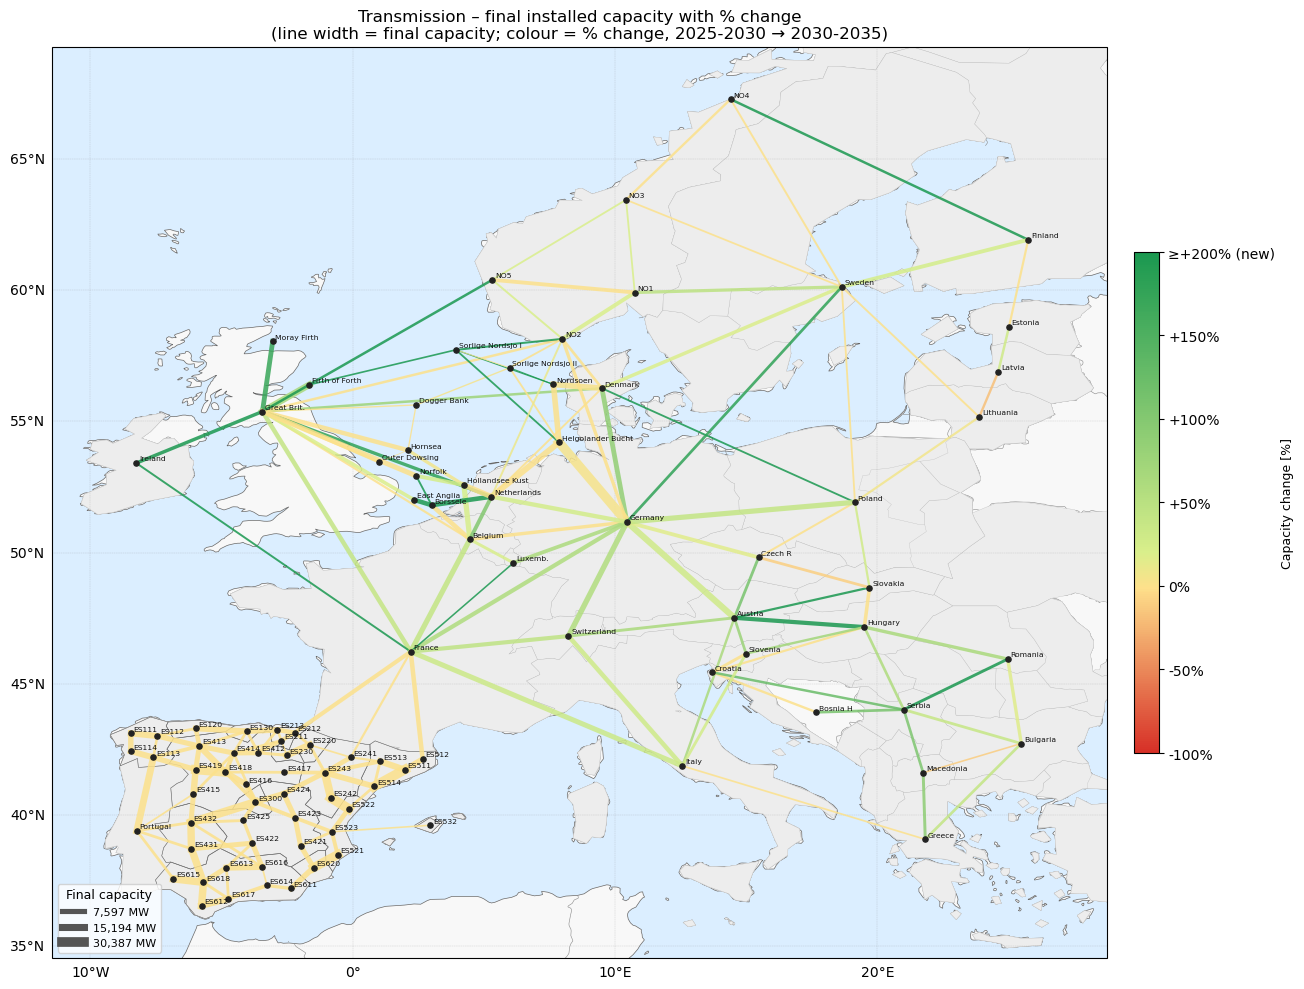

Saved to ..\Results\basic_run\dataset_ES_GoRES\plots\transmission_final_capacity_pct_change.png


In [14]:
# ── Plot: ALL transmission lines in the final period, coloured by % capacity change ──
# Line width  = final installed capacity
# Line colour = diverging spectrum: red (decrease) → grey (no change) → green (increase)

import matplotlib.colors as mcolors

_t3_first = line_periods[0]
_t3_last  = line_periods[-1]
print(f"Full transmission map: {_t3_first} → {_t3_last}")

# ── Build per-link table (first & last period) ─────────────────────────────
_trans3 = pd.read_csv(RESULTS_PATH / 'Output' / 'results_output_transmision.csv')
_trans3['transmissionInstalledCap_MW'] = pd.to_numeric(
    _trans3['transmissionInstalledCap_MW'], errors='coerce').fillna(0.0)
_trans3['Period'] = _trans3['Period'].astype(str)
if YEAR_SHIFT:
    _trans3['Period'] = _trans3['Period'].map(lambda x: shift_period_label(x, YEAR_SHIFT))
_trans3['u'] = _trans3.apply(
    lambda r: normalize_name(r['BetweenNode']) if normalize_name(r['BetweenNode']) <= normalize_name(r['AndNode'])
              else normalize_name(r['AndNode']), axis=1)
_trans3['v'] = _trans3.apply(
    lambda r: normalize_name(r['AndNode']) if normalize_name(r['BetweenNode']) <= normalize_name(r['AndNode'])
              else normalize_name(r['BetweenNode']), axis=1)
_trans3 = _trans3.groupby(['Period', 'u', 'v'], as_index=False)['transmissionInstalledCap_MW'].max()

_f3 = _trans3.loc[_trans3['Period'] == _t3_first, ['u', 'v', 'transmissionInstalledCap_MW']].rename(
    columns={'transmissionInstalledCap_MW': 'cap_first'})
_l3 = _trans3.loc[_trans3['Period'] == _t3_last,  ['u', 'v', 'transmissionInstalledCap_MW']].rename(
    columns={'transmissionInstalledCap_MW': 'cap_last'})

_all3 = _f3.merge(_l3, on=['u', 'v'], how='outer').fillna(0.0)
_all3['delta_MW']  = _all3['cap_last'] - _all3['cap_first']

# % change: new links (cap_first ≈ 0) → +inf → clamp to +200 %; removed → -100 %
def _pct3(row):
    if row['cap_first'] < 1.0:
        return 200.0 if row['cap_last'] > 1.0 else 0.0
    return row['delta_MW'] / row['cap_first'] * 100.0

_all3['pct_change'] = _all3.apply(_pct3, axis=1)

# ── Attach coordinates ─────────────────────────────────────────────────────
_coord_lu3 = coords[['norm_node', 'Latitude', 'Longitude']].drop_duplicates('norm_node')
_all3 = (
    _all3
    .merge(_coord_lu3, left_on='u', right_on='norm_node', how='left')
    .rename(columns={'Latitude': 'lat_u', 'Longitude': 'lon_u'}).drop(columns=['norm_node'])
    .merge(_coord_lu3, left_on='v', right_on='norm_node', how='left')
    .rename(columns={'Latitude': 'lat_v', 'Longitude': 'lon_v'}).drop(columns=['norm_node'])
    .dropna(subset=['lat_u', 'lon_u', 'lat_v', 'lon_v'])
)

# Only keep links with positive final capacity (skip decommissioned + never-built)
_all3 = _all3[_all3['cap_last'] > 1.0].copy()
print(f"Total links plotted: {len(_all3)}")

# ── Colour mapping ──────────────────────────────────────────────────────────
# Clamp % change to [-100, +200] then map to [0, 1] for the colormap
_pct_min, _pct_max = -100.0, 200.0
_cmap = mcolors.LinearSegmentedColormap.from_list(
    'trans_pct',
    [
        (0.0,  '#d73027'),   # -100 %  → red
        (0.33, '#fee08b'),   # ~0 %    → yellow
        (0.40, '#d9ef8b'),   # small + → light green
        (1.0,  '#1a9850'),   # +200 %  → dark green
    ],
)

def _pct_to_colour(pct):
    t = (max(_pct_min, min(_pct_max, pct)) - _pct_min) / (_pct_max - _pct_min)
    return _cmap(t)

max_cap3   = float(_all3['cap_last'].max())
min_lw3, max_lw3 = 0.4, 7.0

# ── Draw ───────────────────────────────────────────────────────────────────
projection3 = ccrs.PlateCarree()
fig3, ax3 = plt.subplots(figsize=(14, 10), subplot_kw={'projection': projection3})
ax3.add_feature(cfeature.OCEAN,     facecolor='#dbeeff', zorder=0)
ax3.add_feature(cfeature.LAND,      facecolor='#f8f8f8', zorder=0)
ax3.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='#666666', zorder=1)
ax3.add_feature(cfeature.BORDERS,   linewidth=0.4, edgecolor='#888888', zorder=1)
if BASEMAP_FILE.exists():
    ax3.add_geometries(load_geojson_geometries(BASEMAP_FILE), crs=GEOJSON_SOURCE_CRS,
                       facecolor='#ededed', edgecolor='#b6b6b6', linewidth=0.2, zorder=1)
    nuts2_borders3 = load_nuts2_country_borders(BASEMAP_FILE, NUTS2_COUNTRIES)
    if nuts2_borders3:
        ax3.add_geometries(nuts2_borders3, crs=GEOJSON_SOURCE_CRS, facecolor='none',
                           edgecolor='#6B6B6B', linewidth=0.4, zorder=3)

for _, lnk3 in _all3.iterrows():
    lw3    = min_lw3 + (max_lw3 - min_lw3) * np.sqrt(float(lnk3['cap_last']) / max_cap3)
    color3 = _pct_to_colour(float(lnk3['pct_change']))
    ax3.plot([lnk3['lon_u'], lnk3['lon_v']], [lnk3['lat_u'], lnk3['lat_v']],
             color=color3, linewidth=lw3, alpha=0.85, transform=projection3, zorder=4)

# Node dots
_all_nodes3 = pd.concat([
    _all3[['u', 'lat_u', 'lon_u']].rename(columns={'u': 'norm_node', 'lat_u': 'Latitude', 'lon_u': 'Longitude'}),
    _all3[['v', 'lat_v', 'lon_v']].rename(columns={'v': 'norm_node', 'lat_v': 'Latitude', 'lon_v': 'Longitude'}),
]).drop_duplicates('norm_node')
ax3.scatter(_all_nodes3['Longitude'], _all_nodes3['Latitude'], s=14, color='#222222',
            zorder=6, transform=projection3)

_name_map3 = coords[['norm_node', 'Location']].drop_duplicates('norm_node').set_index('norm_node')['Location']
for _, _row3 in _all_nodes3.iterrows():
    _label3 = _name_map3.get(_row3['norm_node'], _row3['norm_node'])
    ax3.text(_row3['Longitude'] + 0.10, _row3['Latitude'] + 0.10, str(_label3),
             fontsize=5.5, color='#111111', transform=projection3, zorder=7)

all_lons3 = pd.concat([_all3['lon_u'], _all3['lon_v']])
all_lats3 = pd.concat([_all3['lat_u'], _all3['lat_v']])
ax3.set_extent([all_lons3.min()-3, all_lons3.max()+3, all_lats3.min()-2, all_lats3.max()+2], crs=projection3)
gl3 = ax3.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.4, linestyle='--', zorder=2)
gl3.top_labels = False; gl3.right_labels = False
ax3.set_title(
    f"Transmission – final installed capacity with % change\n"
    f"(line width = final capacity; colour = % change, {_t3_first} → {_t3_last})"
 )

# ── Colorbar ───────────────────────────────────────────────────────────────
sm3 = plt.cm.ScalarMappable(cmap=_cmap, norm=mcolors.Normalize(vmin=_pct_min, vmax=_pct_max))
sm3.set_array([])
cbar3 = plt.colorbar(sm3, ax=ax3, shrink=0.55, pad=0.02, orientation='vertical')
cbar3.set_label('Capacity change [%]', fontsize=9)
cbar3.set_ticks([-100, -50, 0, 50, 100, 150, 200])
cbar3.set_ticklabels(['-100%', '-50%', '0%', '+50%', '+100%', '+150%', '≥+200% (new)'])

# ── Line-width legend ──────────────────────────────────────────────────────
_ref_caps = [0.25 * max_cap3, 0.5 * max_cap3, max_cap3]
_size_handles3 = [
    Line2D([0], [0], color='#555', lw=min_lw3 + (max_lw3 - min_lw3) * np.sqrt(v / max_cap3),
           label=f'{v:,.0f} MW')
    for v in _ref_caps
]
ax3.legend(handles=_size_handles3, loc='lower left', title='Final capacity', title_fontsize=9, fontsize=8)

plt.tight_layout()
plt.savefig(PLOT_DIR / 'transmission_final_capacity_pct_change.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {PLOT_DIR / 'transmission_final_capacity_pct_change.png'}")


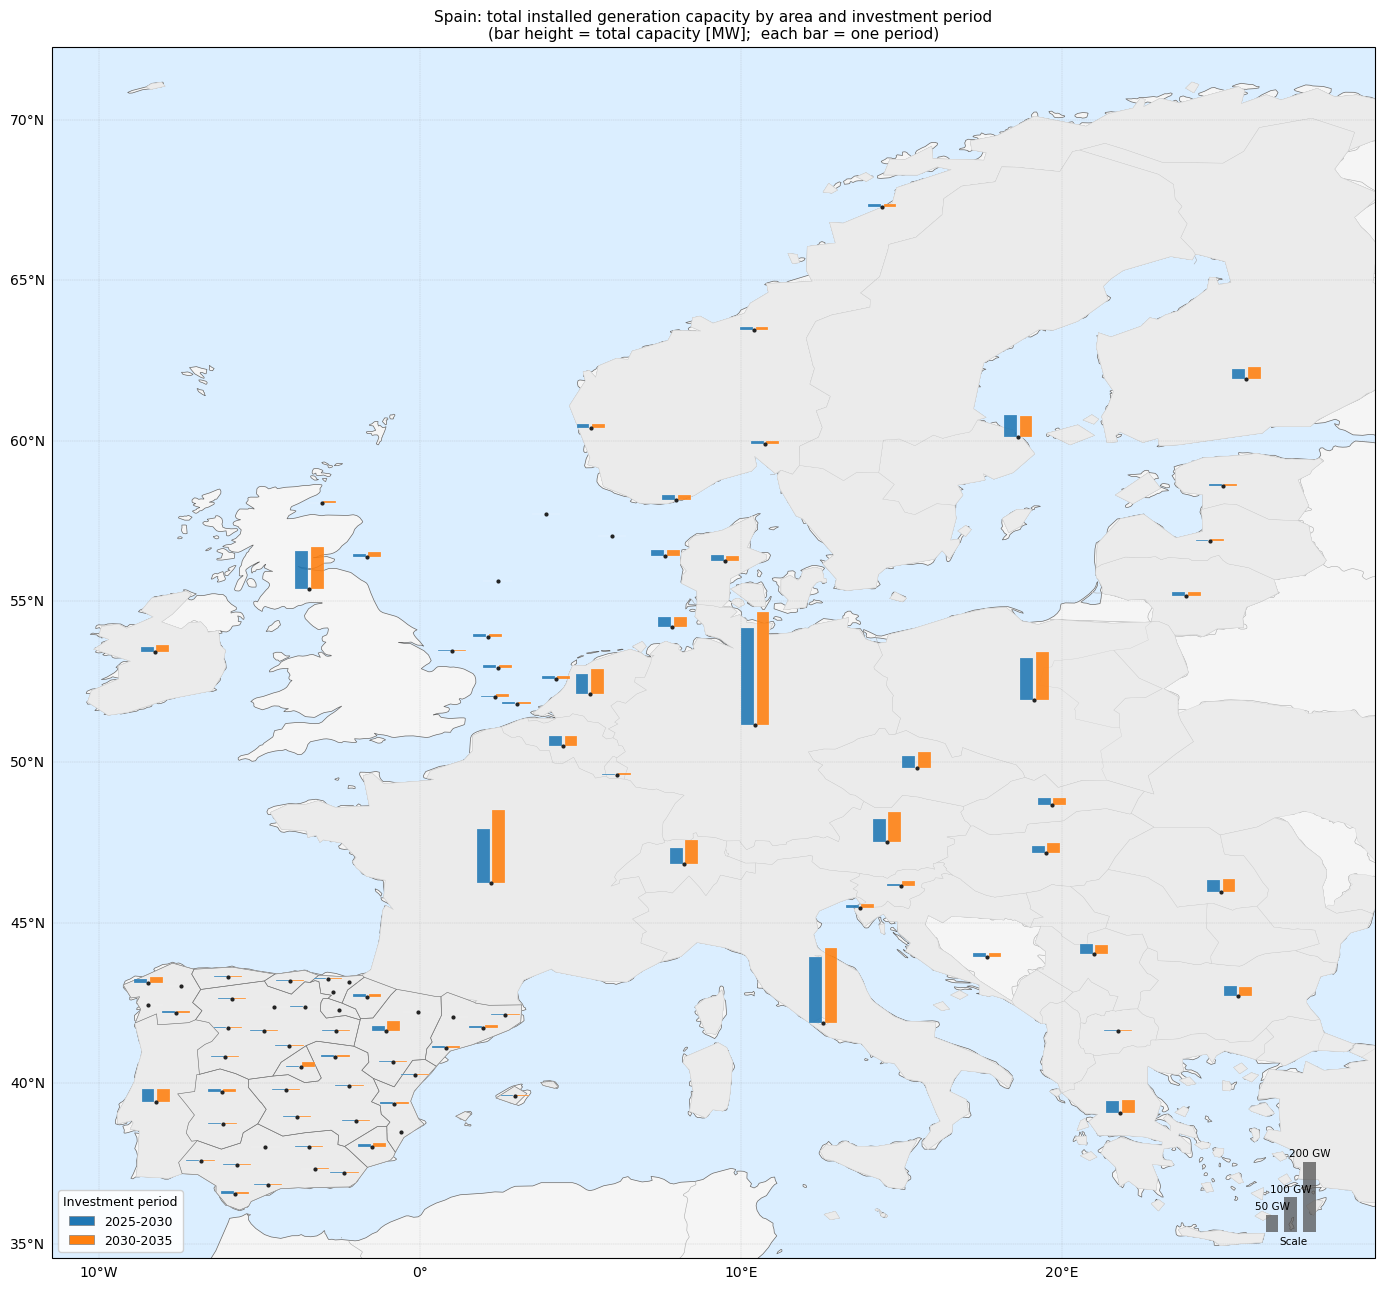

Saved → ..\Results\basic_run\dataset_ES_GoRES\plots\gen_capacity_bars_by_area.png


In [15]:
# ── Plot: total installed generation capacity at each area as grouped bar charts ──
# Each node gets one vertical bar per investment period, drawn at its geographic location.
# Bar height = total installed capacity [MW]  |  colour = investment period

from matplotlib.patches import Rectangle

# ── Aggregate capacity per node per period ─────────────────────────────────
_cap_rows4 = []
for p in gen_periods:
    cap = capacity_by_period[p].copy()
    if AGGREGATE_OFFSHORE_TO_CLOSEST_ONSHORE:
        cap = aggregate_offshore_to_nearest_onshore(cap, coords, offshore_norm_nodes, offshore_to_onshore)
    cap['period']    = p
    cap['total_cap'] = cap[TECH_ORDER].sum(axis=1)
    _cap_rows4.append(cap[['norm_node', 'Node', 'period', 'total_cap']])

_cap4 = pd.concat(_cap_rows4, ignore_index=True)

_coord_lu4 = coords[['norm_node', 'Latitude', 'Longitude']].drop_duplicates('norm_node')
_cap4 = _cap4.merge(_coord_lu4, on='norm_node', how='left').dropna(subset=['Latitude', 'Longitude'])

# ── Bar geometry ────────────────────────────────────────────────────────────
n_p4        = len(gen_periods)
bar_w4      = 0.40               # width of a single bar  [degrees lon]
bar_gap4    = 0.08               # gap between bars in a group
group_w4    = n_p4 * bar_w4 + (n_p4 - 1) * bar_gap4
bar_h_max4  = 3.5               # height for the maximum capacity node [degrees lat]

max_cap4 = float(_cap4['total_cap'].max())

def _h4(cap):
    """Linear height mapping MW → degrees."""
    return (cap / max_cap4) * bar_h_max4

# One distinct colour per period
_period_colors4 = [plt.cm.tab10(i) for i in range(n_p4)]
_period_color_map4 = dict(zip(gen_periods, _period_colors4))

# ── Draw ────────────────────────────────────────────────────────────────────
projection4 = ccrs.PlateCarree()
fig4, ax4 = plt.subplots(figsize=(16, 13), subplot_kw={'projection': projection4})
ax4.add_feature(cfeature.OCEAN,     facecolor='#dbeeff', zorder=0)
ax4.add_feature(cfeature.LAND,      facecolor='#f5f5f5', zorder=0)
ax4.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='#666', zorder=1)
ax4.add_feature(cfeature.BORDERS,   linewidth=0.4, edgecolor='#aaa', zorder=1)
if BASEMAP_FILE.exists():
    ax4.add_geometries(load_geojson_geometries(BASEMAP_FILE), crs=GEOJSON_SOURCE_CRS,
                       facecolor='#ebebeb', edgecolor='#c5c5c5', linewidth=0.2, zorder=1)
    nuts2_borders4 = load_nuts2_country_borders(BASEMAP_FILE, NUTS2_COUNTRIES)
    if nuts2_borders4:
        ax4.add_geometries(nuts2_borders4, crs=GEOJSON_SOURCE_CRS,
                           facecolor='none', edgecolor='#777', linewidth=0.4, zorder=2)

# Group by node and draw bars
_node_coords4 = (
    _cap4[['norm_node', 'Latitude', 'Longitude']]
    .drop_duplicates('norm_node')
    .set_index('norm_node')
)

for norm_node, grp in _cap4.groupby('norm_node'):
    if norm_node not in _node_coords4.index:
        continue
    lat0 = float(_node_coords4.loc[norm_node, 'Latitude'])
    lon0 = float(_node_coords4.loc[norm_node, 'Longitude'])

    period_caps = grp.set_index('period')['total_cap'].reindex(gen_periods, fill_value=0.0)
    if period_caps.sum() < 1.0:
        continue

    x_start = lon0 - group_w4 / 2

    for j, p in enumerate(gen_periods):
        val = float(period_caps[p])
        if val < 1.0:
            continue
        h = _h4(val)
        x = x_start + j * (bar_w4 + bar_gap4)
        ax4.add_patch(Rectangle(
            (x, lat0), bar_w4, h,
            facecolor=_period_color_map4[p],
            edgecolor='white', linewidth=0.15,
            alpha=0.88,
            transform=projection4, zorder=4,
        ))

    # Node anchor dot
    ax4.plot(lon0, lat0, 'o', color='#222', markersize=2.0,
             transform=projection4, zorder=5)

# ── Map extent (leave room above for tallest bars) ─────────────────────────
_lons4 = _cap4['Longitude']
_lats4 = _cap4['Latitude']
ax4.set_extent(
    [_lons4.min() - 3, _lons4.max() + 4,
     _lats4.min() - 2, _lats4.max() + bar_h_max4 + 1.5],
    crs=projection4,
)
gl4 = ax4.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.4, linestyle='--', zorder=2)
gl4.top_labels = False; gl4.right_labels = False

# ── Reference scale bar (bottom-right corner) ──────────────────────────────
_ref_caps_mw  = [50_000, 100_000, 200_000]
_ref_lon_base = float(_lons4.max()) + 0.6
_ref_lat_base = float(_lats4.min()) - 1.2
for k, ref_mw in enumerate(_ref_caps_mw):
    _rx = _ref_lon_base + k * (bar_w4 + bar_gap4 + 0.1)
    _rh = _h4(ref_mw)
    ax4.add_patch(Rectangle(
        (_rx, _ref_lat_base), bar_w4, _rh,
        facecolor='#555', edgecolor='none', alpha=0.75,
        transform=projection4, zorder=6,
    ))
    ax4.text(_rx + bar_w4 / 2, _ref_lat_base + _rh + 0.1,
             f'{ref_mw // 1000} GW', fontsize=7.5, ha='center', va='bottom',
             transform=projection4, zorder=7)
ax4.text(
    _ref_lon_base + len(_ref_caps_mw) * (bar_w4 + bar_gap4 + 0.1) / 2,
    _ref_lat_base - 0.35, 'Scale', fontsize=7.5, ha='center',
    transform=projection4, zorder=7,
)

# ── Legend: period colours ─────────────────────────────────────────────────
_leg4 = [
    Patch(facecolor=_period_color_map4[p], edgecolor='grey', linewidth=0.5, label=p)
    for p in gen_periods
]
ax4.legend(handles=_leg4, loc='lower left',
           title='Investment period', title_fontsize=9, fontsize=9, framealpha=0.9)

ax4.set_title(
    f'{FOCUSED_AREA}: total installed generation capacity by area and investment period\n'
    '(bar height = total capacity [MW];  each bar = one period)',
    fontsize=11,
)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'gen_capacity_bars_by_area.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {PLOT_DIR / 'gen_capacity_bars_by_area.png'}")


In [16]:
# ── Table: total installed generation capacity [MW] by area and period ──────
_tbl = (
    _cap4[['Node', 'period', 'total_cap']]
    .pivot_table(index='Node', columns='period', values='total_cap', aggfunc='sum')
    .reindex(columns=gen_periods)          # keep period order
    .sort_values(gen_periods[-1], ascending=False)  # sort by last period
)
_tbl.columns.name = None
_tbl.index.name   = 'Area'

# Add a change column (last − first) and % change
_tbl['Δ MW (last−first)']  = _tbl[gen_periods[-1]] - _tbl[gen_periods[0]]
_tbl['Δ % (last−first)']   = (_tbl['Δ MW (last−first)'] / _tbl[gen_periods[0]].replace(0, float('nan')) * 100)

# Format: round MW to 1 decimal, % to 1 decimal
_fmt = {p: '{:,.1f}' for p in gen_periods}
_fmt['Δ MW (last−first)'] = '{:+,.1f}'
_fmt['Δ % (last−first)']  = '{:+.1f}'

display(
    _tbl.style
    .format(_fmt, na_rep='—')
    .background_gradient(subset=gen_periods, cmap='YlOrRd', axis=None)
    .bar(subset=['Δ MW (last−first)'], align='zero', color=['#d73027', '#1a9850'])
    .set_caption(
        f'Total installed generation capacity [MW] by area — '
        f'{gen_periods[0]} → {gen_periods[-1]}'
    )
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '13px'), ('font-weight', 'bold'), ('text-align', 'left')]},
        {'selector': 'th',      'props': [('text-align', 'center'), ('white-space', 'nowrap')]},
        {'selector': 'td',      'props': [('text-align', 'right'),  ('padding', '4px 10px')]},
    ])
)

# Also print a plain-text summary at the bottom
print(f"\nTotal across all areas:")
for p in gen_periods:
    print(f"  {p}: {_tbl[p].sum():>12,.1f} MW")
print(f"  Δ (last−first): {_tbl['Δ MW (last−first)'].sum():>+12,.1f} MW")

,2025-2030,2030-2035,Δ MW (last−first),Δ % (last−first)
Area,,,,
Germany,"272,176.6","317,838.9","+45,662.3",+16.8
Italy,"187,022.6","212,087.7","+25,065.1",+13.4
France,"153,233.6","207,499.1","+54,265.5",+35.4
Poland,"119,828.9","137,317.7","+17,488.8",+14.6
GreatBrit.,"109,789.1","120,894.5","+11,105.4",+10.1
Austria,"65,512.8","83,983.1","+18,470.2",+28.2
Netherlands,"56,613.5","68,455.6","+11,842.1",+20.9
Switzerland,"46,789.8","67,233.6","+20,443.7",+43.7
Sweden,"60,646.7","57,859.9","-2,786.8",-4.6



Total across all areas:
  2025-2030:  1,751,505.1 MW
  2030-2035:  2,048,591.2 MW
  Δ (last−first):   +297,086.0 MW


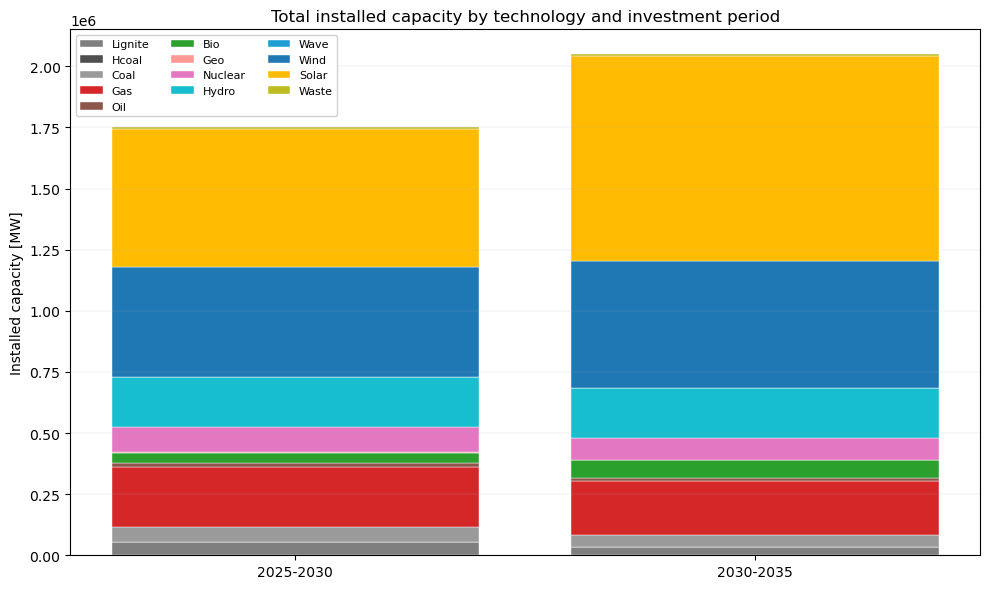

Saved → ..\Results\basic_run\dataset_ES_GoRES\plots\total_installed_capacity_stacked.png


In [17]:
# ── Plot: total installed capacity by technology (stacked) ──────────────────
_rows_stack = []
for p in gen_periods:
    cap = capacity_by_period[p].copy()
    if AGGREGATE_OFFSHORE_TO_CLOSEST_ONSHORE:
        cap = aggregate_offshore_to_nearest_onshore(cap, coords, offshore_norm_nodes, offshore_to_onshore)
    totals = cap[TECH_ORDER].sum(axis=0)
    totals.name = p
    _rows_stack.append(totals)

_stack_df = pd.DataFrame(_rows_stack).reindex(columns=TECH_ORDER, fill_value=0.0)
_stack_df.index = gen_periods

fig, ax = plt.subplots(figsize=(10, 6))
bottom = np.zeros(len(_stack_df))
x = np.arange(len(_stack_df.index))

for tech in TECH_ORDER:
    vals = _stack_df[tech].values
    ax.bar(x, vals, bottom=bottom, color=TECH_COLORS[tech], edgecolor="white", linewidth=0.3, label=tech)
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(_stack_df.index, rotation=0)
ax.set_ylabel("Installed capacity [MW]")
ax.set_title("Total installed capacity by technology and investment period")
ax.legend(ncol=3, fontsize=8, framealpha=0.9)
ax.grid(axis="y", linewidth=0.3, alpha=0.4)
plt.tight_layout()
plt.savefig(PLOT_DIR / "total_installed_capacity_stacked.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {PLOT_DIR / 'total_installed_capacity_stacked.png'}")

## Capacity maps by technology group

In [18]:
# ── Helper: draw grouped bar-chart map for a technology subset ───────────────
def plot_tech_cap_bars(tech_list: list[str], group_title: str, save_name: str,
                       bar_h_max: float = 3.0, ref_caps_mw: list[int] | None = None):
    """
    Draw one bar per node per investment period, sized by total installed
    capacity [MW] for the technologies in *tech_list*.
    """
    if ref_caps_mw is None:
        ref_caps_mw = [10_000, 50_000, 100_000]

    # ── Aggregate ──────────────────────────────────────────────────────────
    _rows = []
    for p in gen_periods:
        cap = capacity_by_period[p].copy()
        if AGGREGATE_OFFSHORE_TO_CLOSEST_ONSHORE:
            cap = aggregate_offshore_to_nearest_onshore(
                cap, coords, offshore_norm_nodes, offshore_to_onshore)
        cap['period']    = p
        avail = [t for t in tech_list if t in cap.columns]
        cap['tech_cap']  = cap[avail].sum(axis=1) if avail else 0.0
        _rows.append(cap[['norm_node', 'Node', 'period', 'tech_cap']])

    _cap = pd.concat(_rows, ignore_index=True)
    _coord_lu = coords[['norm_node', 'Latitude', 'Longitude']].drop_duplicates('norm_node')
    _cap = _cap.merge(_coord_lu, on='norm_node', how='left').dropna(subset=['Latitude', 'Longitude'])
    _cap = _cap[_cap['tech_cap'] > 0.0]

    if _cap.empty:
        print(f"No data for: {group_title}")
        return

    # ── Bar geometry ───────────────────────────────────────────────────────
    n_p       = len(gen_periods)
    bar_w     = 0.40
    bar_gap   = 0.08
    group_w   = n_p * bar_w + (n_p - 1) * bar_gap
    max_cap   = float(_cap['tech_cap'].max())

    def _h(cap):
        return (cap / max_cap) * bar_h_max

    _period_colors    = [plt.cm.tab10(i) for i in range(n_p)]
    _period_color_map = dict(zip(gen_periods, _period_colors))

    # ── Draw ───────────────────────────────────────────────────────────────
    proj = ccrs.PlateCarree()
    fig, ax = plt.subplots(figsize=(16, 13), subplot_kw={'projection': proj})
    ax.add_feature(cfeature.OCEAN,     facecolor='#dbeeff', zorder=0)
    ax.add_feature(cfeature.LAND,      facecolor='#f5f5f5', zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='#666', zorder=1)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.4, edgecolor='#aaa', zorder=1)
    if BASEMAP_FILE.exists():
        ax.add_geometries(load_geojson_geometries(BASEMAP_FILE),
                          crs=GEOJSON_SOURCE_CRS,
                          facecolor='#ebebeb', edgecolor='#c5c5c5', linewidth=0.2, zorder=1)
        _nuts2_borders = load_nuts2_country_borders(BASEMAP_FILE, NUTS2_COUNTRIES)
        if _nuts2_borders:
            ax.add_geometries(_nuts2_borders, crs=GEOJSON_SOURCE_CRS,
                              facecolor='none', edgecolor='#777', linewidth=0.4, zorder=2)

    _node_coords = (
        _cap[['norm_node', 'Latitude', 'Longitude']]
        .drop_duplicates('norm_node').set_index('norm_node')
    )
    for norm_node, grp in _cap.groupby('norm_node'):
        if norm_node not in _node_coords.index:
            continue
        lat0 = float(_node_coords.loc[norm_node, 'Latitude'])
        lon0 = float(_node_coords.loc[norm_node, 'Longitude'])
        period_caps = grp.set_index('period')['tech_cap'].reindex(gen_periods, fill_value=0.0)
        if period_caps.sum() < 1.0:
            continue
        x_start = lon0 - group_w / 2
        for j, p in enumerate(gen_periods):
            val = float(period_caps[p])
            if val < 1.0:
                continue
            ax.add_patch(Rectangle(
                (x_start + j * (bar_w + bar_gap), lat0), bar_w, _h(val),
                facecolor=_period_color_map[p], edgecolor='white',
                linewidth=0.15, alpha=0.88, transform=proj, zorder=4,
            ))
        ax.plot(lon0, lat0, 'o', color='#222', markersize=2.0, transform=proj, zorder=5)

    # ── Extent ─────────────────────────────────────────────────────────────
    _lons = _cap['Longitude']
    _lats = _cap['Latitude']
    ax.set_extent(
        [_lons.min() - 3, _lons.max() + 4,
         _lats.min() - 2, _lats.max() + bar_h_max + 1.5],
        crs=proj,
)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.4,
                      linestyle='--', zorder=2)
    gl.top_labels = False; gl.right_labels = False

    # ── Reference scale ────────────────────────────────────────────────────
    _ref_lon_base = float(_lons.max()) + 0.6
    _ref_lat_base = float(_lats.min()) - 1.2
    for k, ref_mw in enumerate(ref_caps_mw):
        _rx = _ref_lon_base + k * (bar_w + bar_gap + 0.1)
        _rh = _h(ref_mw)
        ax.add_patch(Rectangle(
            (_rx, _ref_lat_base), bar_w, _rh,
            facecolor='#555', edgecolor='none', alpha=0.75, transform=proj, zorder=6,
        ))
        ax.text(_rx + bar_w / 2, _ref_lat_base + _rh + 0.1,
                f'{ref_mw // 1000} GW', fontsize=7.5, ha='center', va='bottom',
                transform=proj, zorder=7)
    ax.text(
        _ref_lon_base + len(ref_caps_mw) * (bar_w + bar_gap + 0.1) / 2,
        _ref_lat_base - 0.35, 'Scale', fontsize=7.5, ha='center',
        transform=proj, zorder=7,
)

    # ── Legend ─────────────────────────────────────────────────────────────
    _leg = [Patch(facecolor=_period_color_map[p], edgecolor='grey',
                  linewidth=0.5, label=p) for p in gen_periods]
    ax.legend(handles=_leg, loc='lower left',
              title='Investment period', title_fontsize=9, fontsize=9, framealpha=0.9)
    ax.set_title(
        f'{group_title} — installed capacity by area and investment period\n'
        '(bar height = total capacity [MW];  each bar = one period)',
        fontsize=11,
    )
    plt.tight_layout()
    out = PLOT_DIR / f'{save_name}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {out}")

print("plot_tech_cap_bars() ready.")


plot_tech_cap_bars() ready.


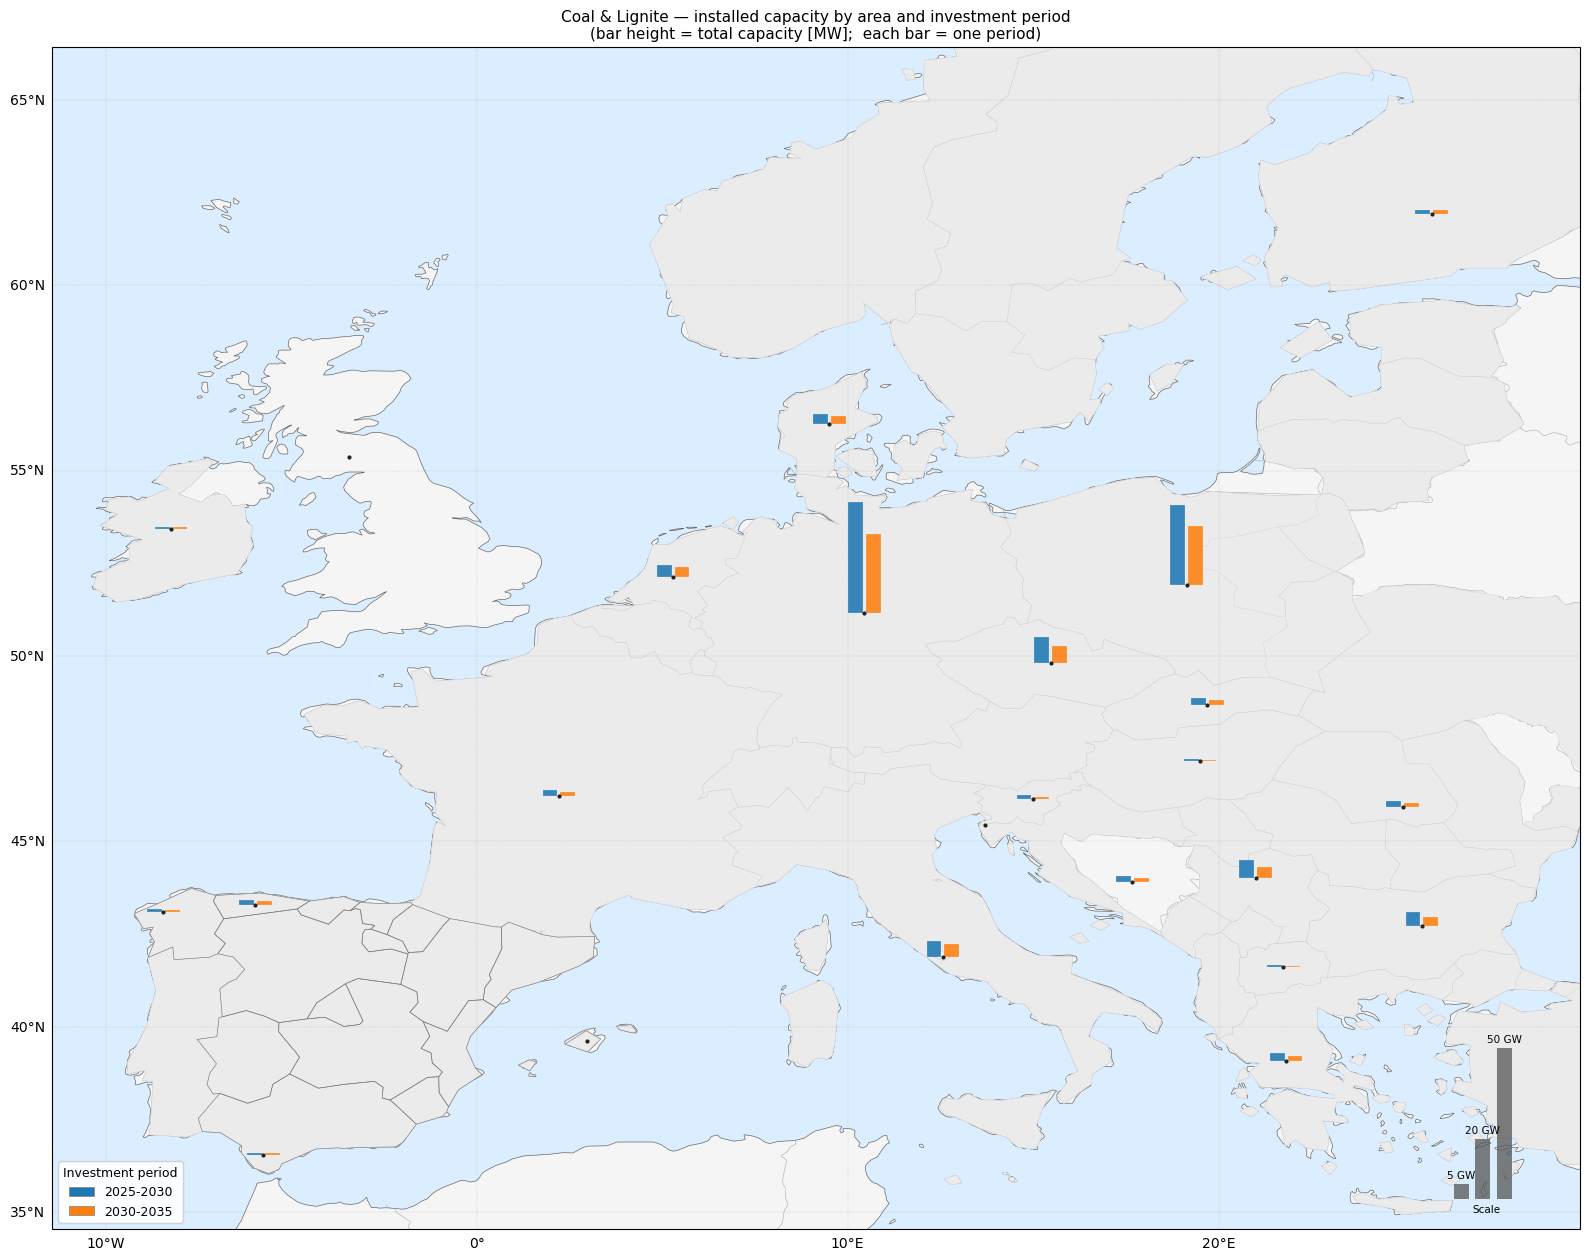

Saved → ..\Results\basic_run\dataset_ES_GoRES\plots\cap_bars_coal_lignite.png


In [19]:
# ── Coal & Lignite capacity map ───────────────────────────────────────────────
plot_tech_cap_bars(
    tech_list   = ["Coal", "Lignite", "Hcoal"],
    group_title = "Coal & Lignite",
    save_name   = "cap_bars_coal_lignite",
    ref_caps_mw = [5_000, 20_000, 50_000],
)

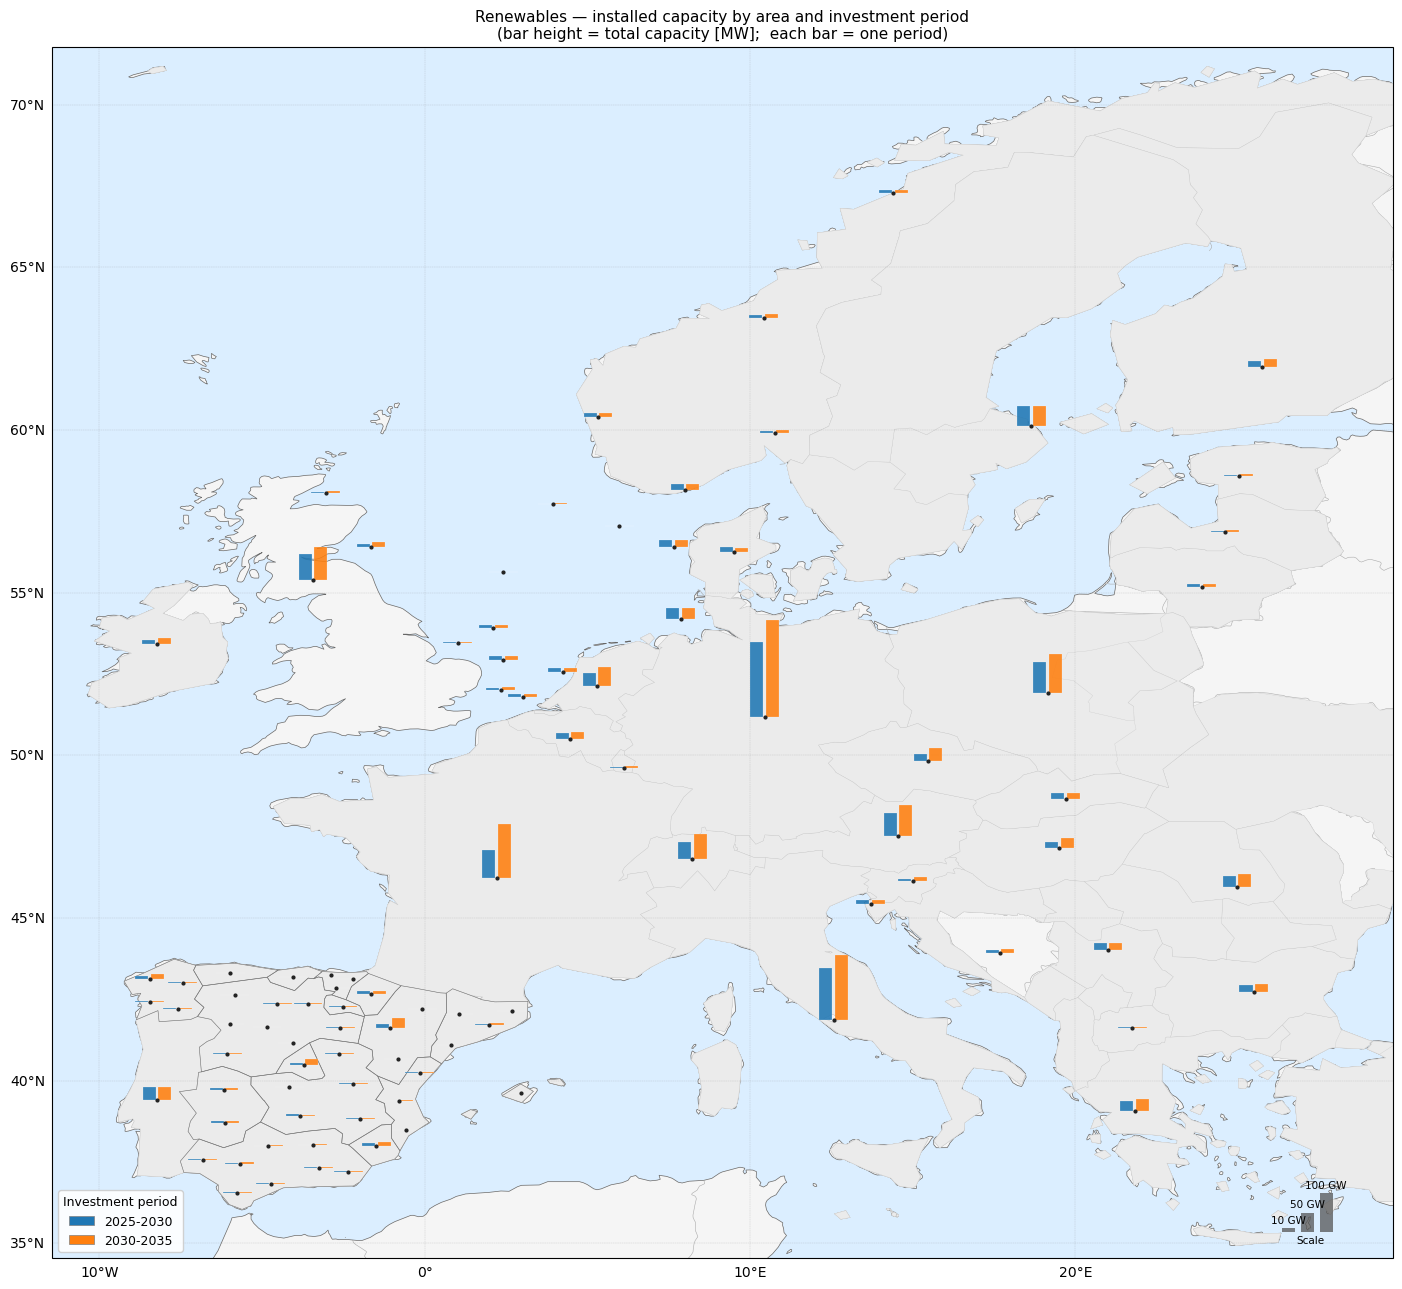

Saved → ..\Results\basic_run\dataset_ES_GoRES\plots\cap_bars_renewables.png


In [20]:
# ── Renewables capacity map ───────────────────────────────────────────────────
plot_tech_cap_bars(
    tech_list   = ["Bio", "Geo", "Hydro", "Wave", "Wind", "Solar", "Waste"],
    group_title = "Renewables",
    save_name   = "cap_bars_renewables",
    ref_caps_mw = [10_000, 50_000, 100_000],
)

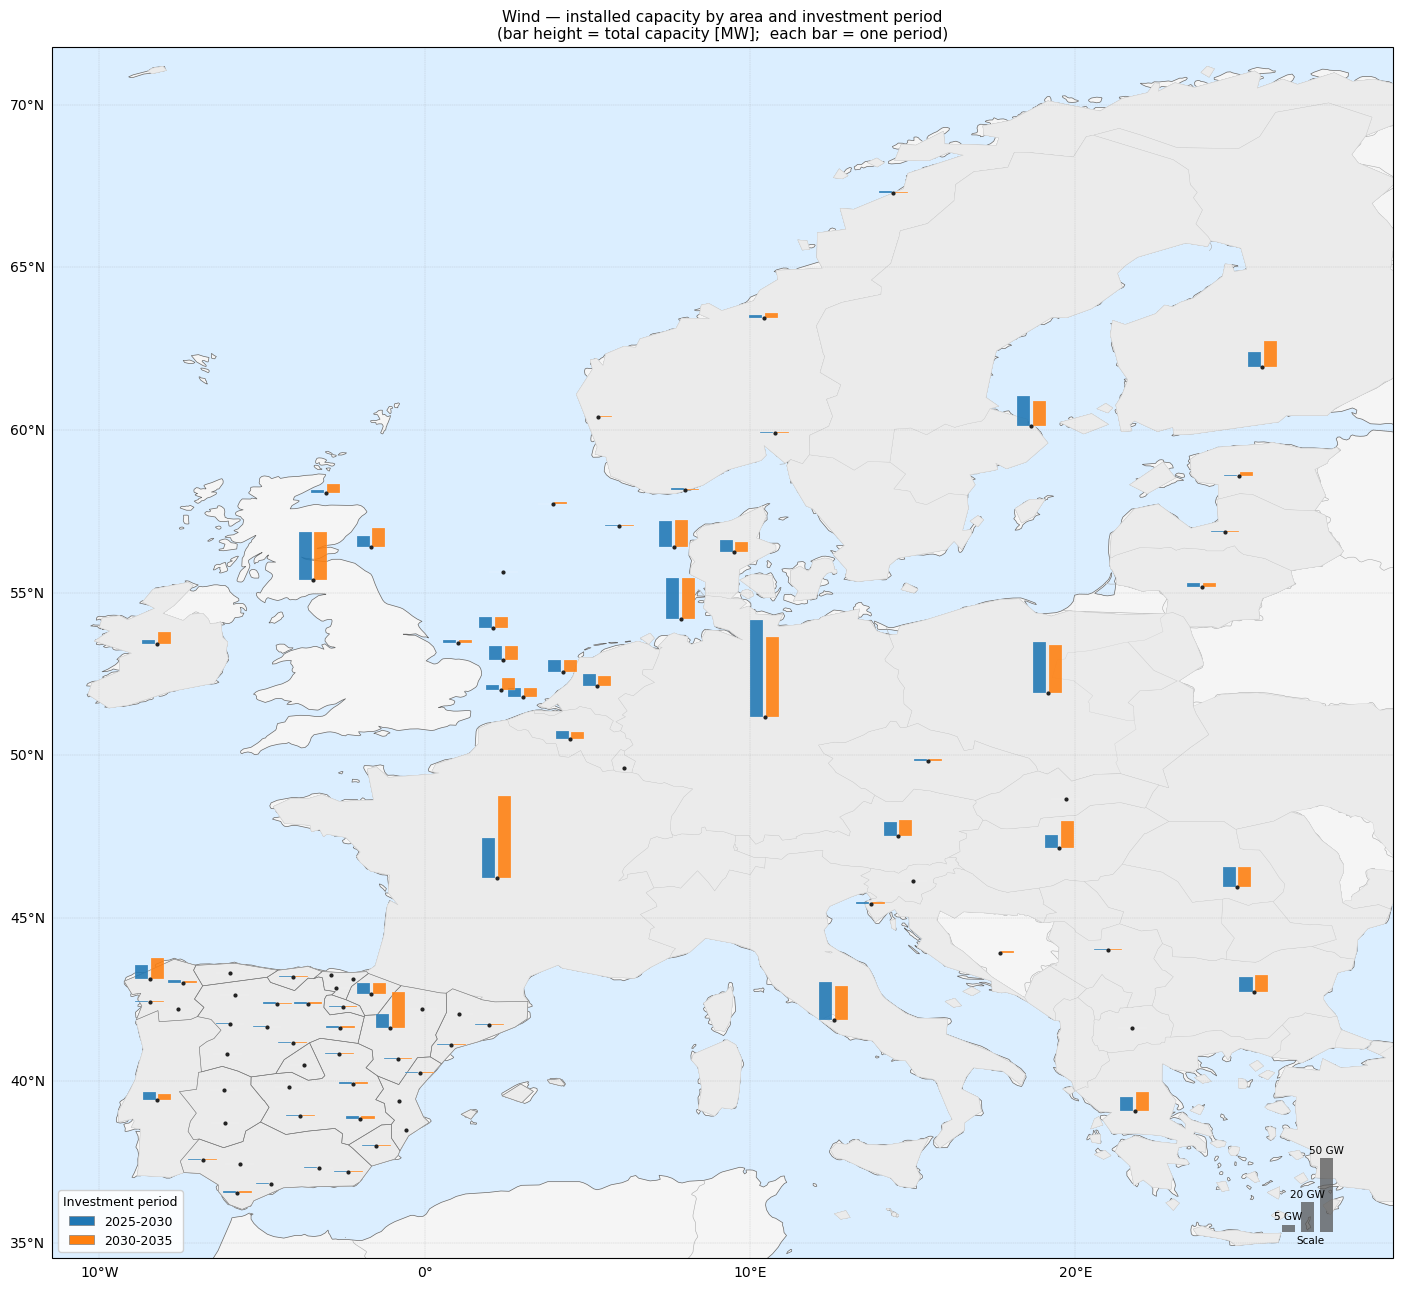

Saved → ..\Results\basic_run\dataset_ES_GoRES\plots\cap_bars_wind.png


In [21]:
# ── Wind capacity map ─────────────────────────────────────────────────────────
plot_tech_cap_bars(
    tech_list   = ["Wind"],
    group_title = "Wind",
    save_name   = "cap_bars_wind",
    ref_caps_mw = [5_000, 20_000, 50_000],
)

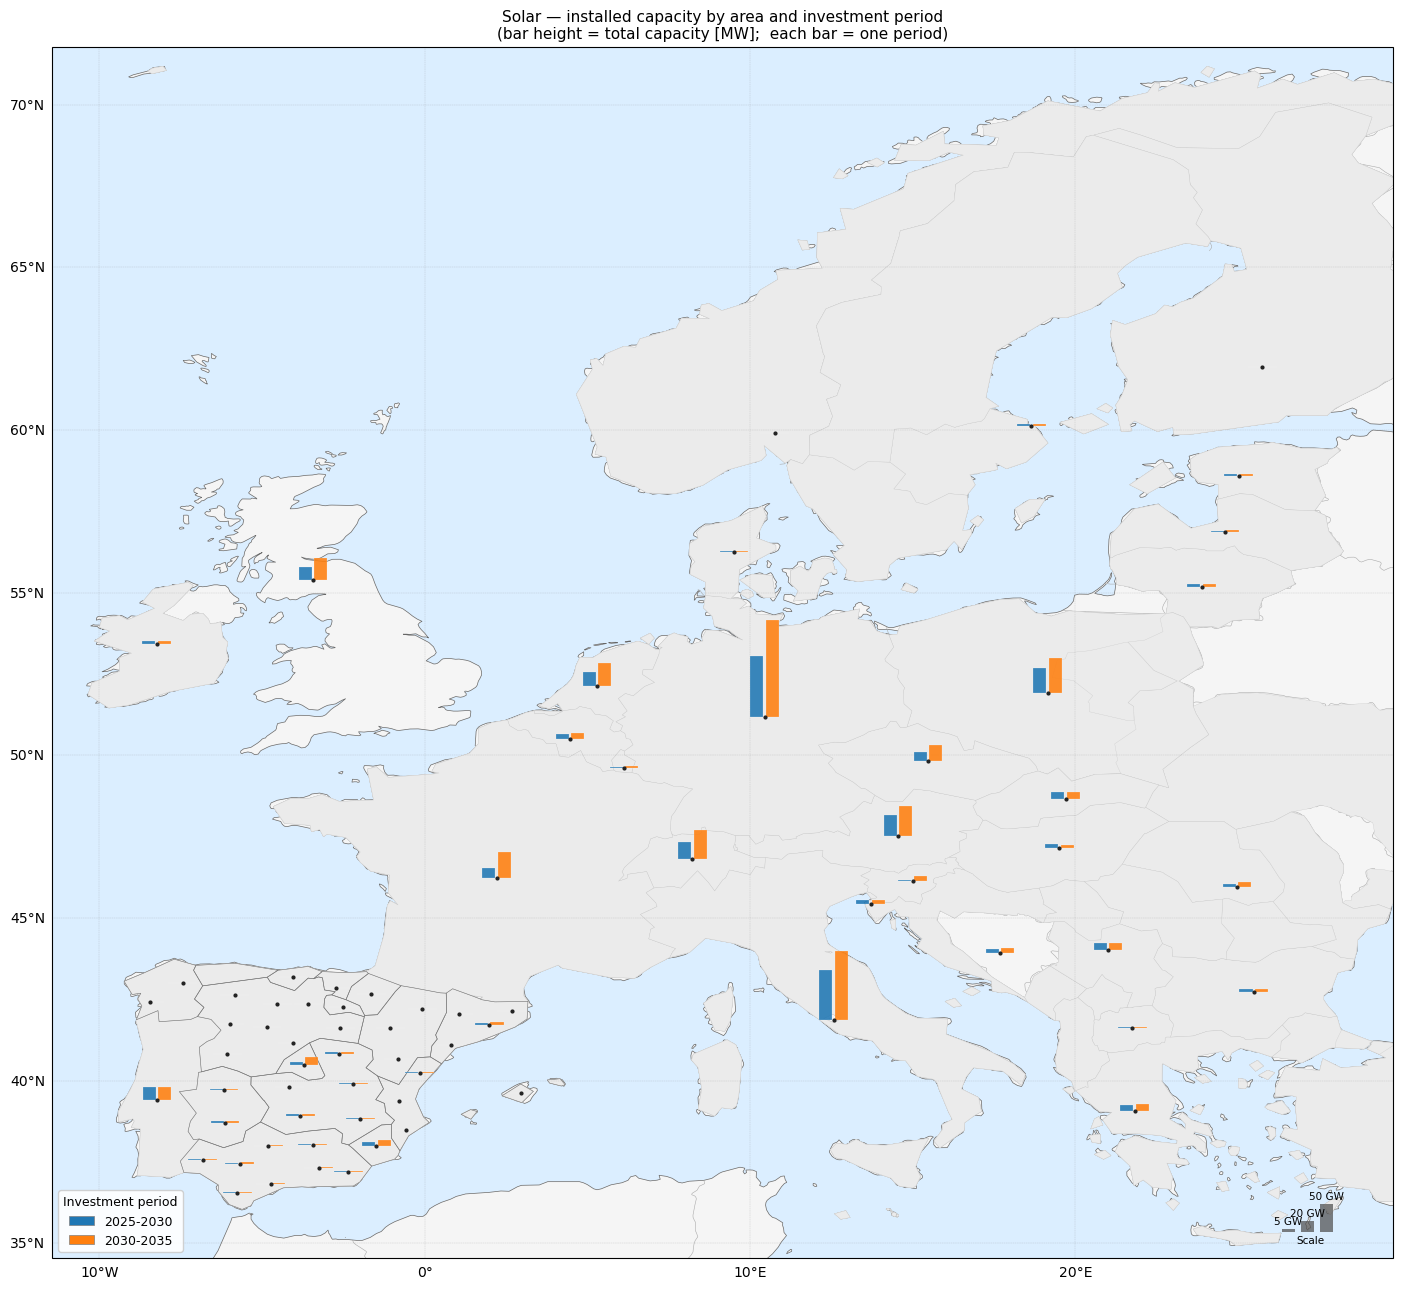

Saved → ..\Results\basic_run\dataset_ES_GoRES\plots\cap_bars_solar.png


In [22]:
# ── Solar capacity map ────────────────────────────────────────────────────────
plot_tech_cap_bars(
    tech_list   = ["Solar"],
    group_title = "Solar",
    save_name   = "cap_bars_solar",
    ref_caps_mw = [5_000, 20_000, 50_000],
)

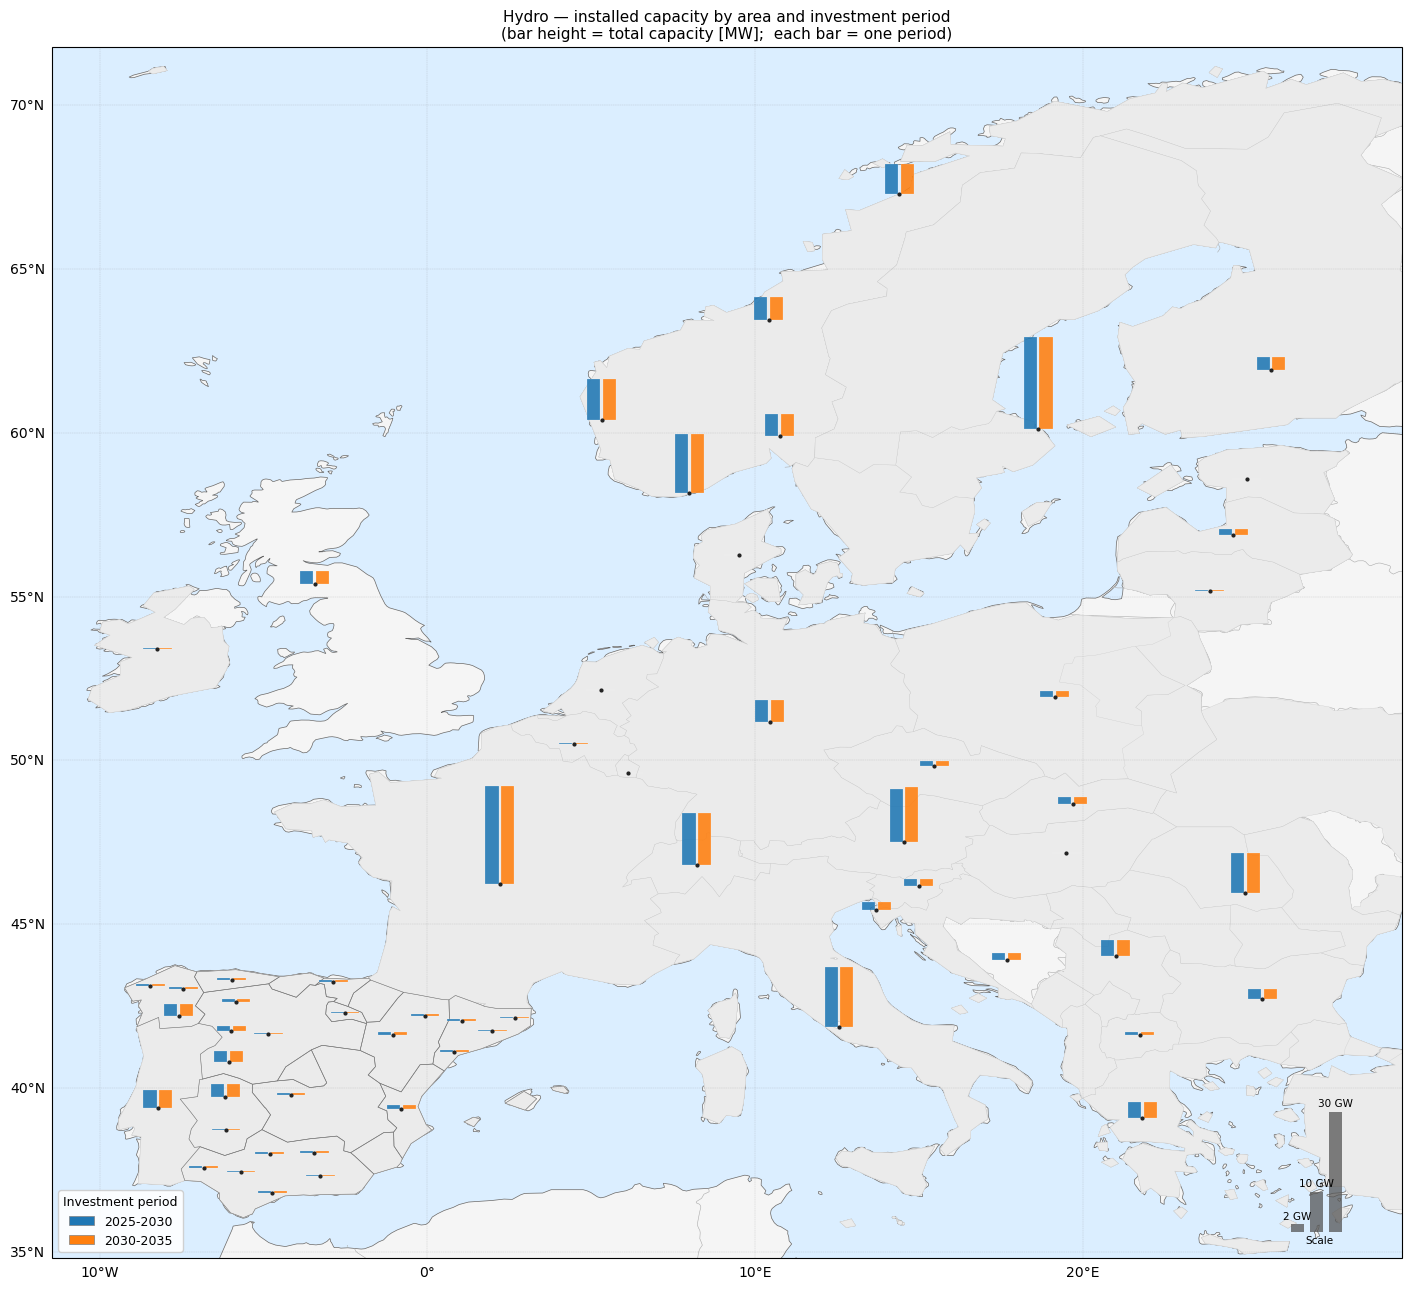

Saved → ..\Results\basic_run\dataset_ES_GoRES\plots\cap_bars_hydro.png


In [23]:
# ── Hydro capacity map ────────────────────────────────────────────────────────
plot_tech_cap_bars(
    tech_list   = ["Hydro"],
    group_title = "Hydro",
    save_name   = "cap_bars_hydro",
    ref_caps_mw = [2_000, 10_000, 30_000],
)

## Hourly generation and load

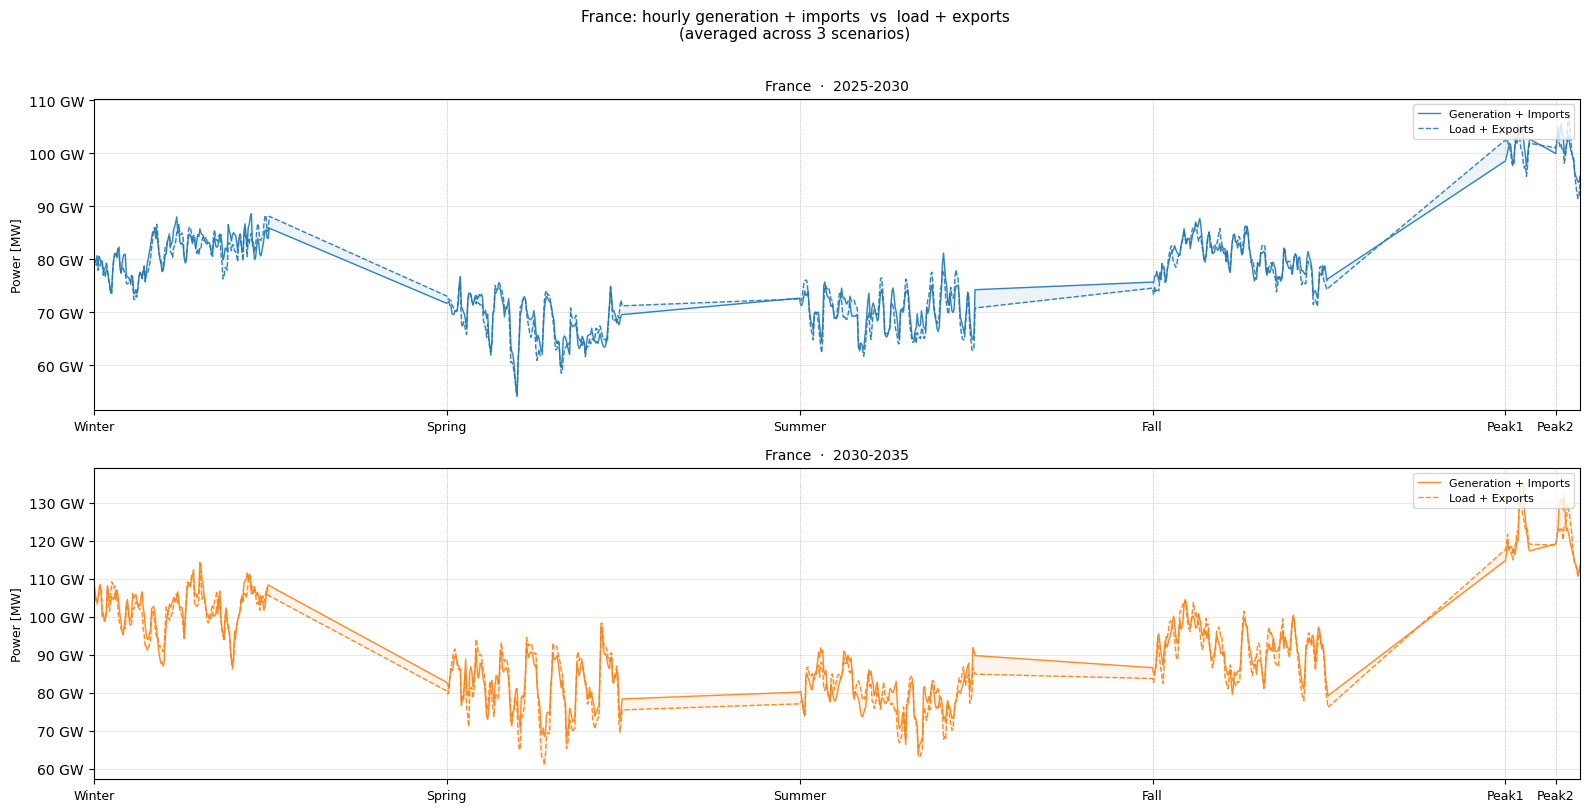

Saved → ..\Results\basic_run\dataset_ES_GoRES\plots\hourly_gen_load_france.png


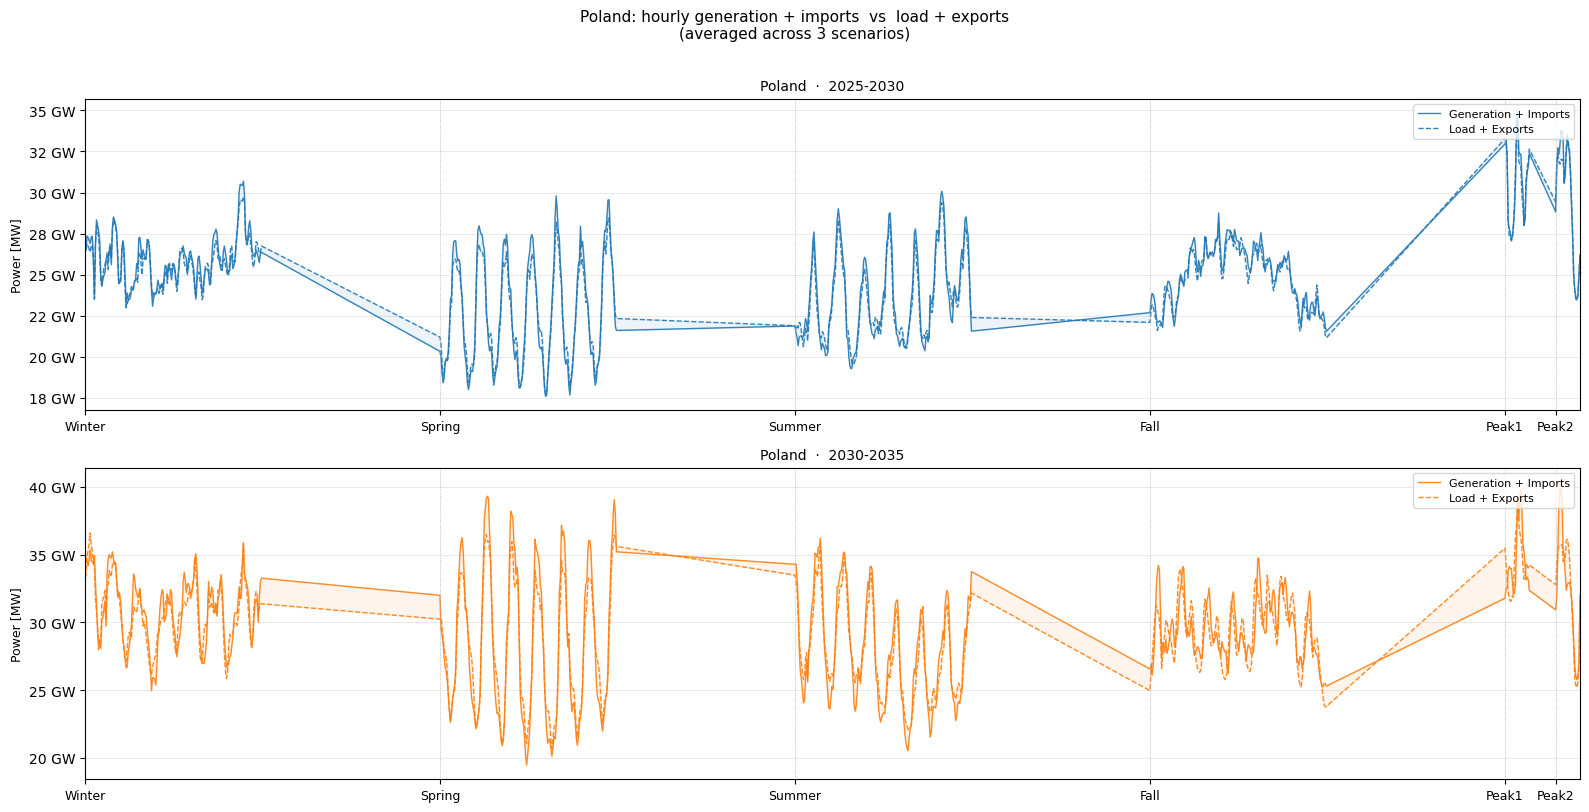

Saved → ..\Results\basic_run\dataset_ES_GoRES\plots\hourly_gen_load_poland.png


In [24]:

# ── Plot: hourly generation vs load for France and Poland (one figure each) ──
#
# Supply  = AllGen_MW  + FlowIn_MW    (generation + imports)
# Demand  = -(Load_MW  + FlowOut_MW)  (consumption + exports, sign-flipped to positive)
#
# Seasons are laid out sequentially: winter → spring → summer → fall → peak1 → peak2
# Values are averaged across scenarios; one line per investment period.

_OP_FILE = RESULTS_PATH / 'Output' / 'results_output_Operational.csv'

_op = pd.read_csv(
    _OP_FILE,
    usecols=['Node', 'Period', 'Scenario', 'Season', 'Hour',
             'AllGen_MW', 'Load_MW', 'FlowOut_MW', 'FlowIn_MW'],
)
if YEAR_SHIFT:
    _op['Period'] = _op['Period'].astype(str).map(lambda x: shift_period_label(x, YEAR_SHIFT))
_op['Supply_MW'] = _op['AllGen_MW'] + _op['FlowIn_MW']
_op['Demand_MW'] = -(_op['Load_MW'] + _op['FlowOut_MW'])

# Average across scenarios
_op_avg = (
    _op.groupby(['Node', 'Period', 'Season', 'Hour'], as_index=False)
    [['Supply_MW', 'Demand_MW']].mean()
)

# Build a sequential x-axis: enumerate (Season, Hour) pairs in a fixed order
_SEASON_ORDER = ['winter', 'spring', 'summer', 'fall', 'peak1', 'peak2']

def _build_time_index(df: pd.DataFrame) -> pd.DataFrame:
    """Attach a monotonic hour_index column to a per-node/period slice."""
    df = df.copy()
    df['season_rank'] = df['Season'].map({s: i for i, s in enumerate(_SEASON_ORDER)})
    df = df.sort_values(['season_rank', 'Hour']).reset_index(drop=True)
    # Cumulative hour index
    _offsets = {}
    _h = 0
    for s in _SEASON_ORDER:
        _offsets[s] = _h
        n = df.loc[df['Season'] == s, 'Hour'].nunique()
        _h += n
    df['hour_index'] = df.apply(
        lambda r: _offsets[r['Season']] + r['Hour'] - 1, axis=1
    )
    return df

# X-tick positions: first hour of each season
def _season_ticks(df):
    ticks, labels = [], []
    for s in _SEASON_ORDER:
        sub = df[df['Season'] == s]
        if not sub.empty:
            ticks.append(int(sub['hour_index'].min()))
            labels.append(s.capitalize())
    return ticks, labels

_PERIOD_COLORS = {
    p: c for p, c in zip(
        sorted(_op['Period'].unique()),
        ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    )
}

_NODES_TO_PLOT = ['France', 'Poland']

for _node in _NODES_TO_PLOT:
    _df_node = _op_avg[_op_avg['Node'] == _node].copy()
    if _df_node.empty:
        print(f"No data for {_node}")
        continue

    fig, axes = plt.subplots(
        len(_df_node['Period'].unique()), 1,
        figsize=(16, 4 * len(_df_node['Period'].unique())),
        sharex=False,
    )
    if len(_df_node['Period'].unique()) == 1:
        axes = [axes]

    for ax, period in zip(axes, sorted(_df_node['Period'].unique())):
        _df_p = _build_time_index(_df_node[_df_node['Period'] == period])
        _color = _PERIOD_COLORS[period]

        ax.plot(_df_p['hour_index'], _df_p['Supply_MW'],
                color=_color, linewidth=1.0, label='Generation + Imports', alpha=0.9)
        ax.plot(_df_p['hour_index'], _df_p['Demand_MW'],
                color=_color, linewidth=1.0, linestyle='--', label='Load + Exports', alpha=0.9)
        ax.fill_between(_df_p['hour_index'],
                        _df_p['Supply_MW'], _df_p['Demand_MW'],
                        alpha=0.08, color=_color)

        # Season separators & x-ticks
        _ticks, _labels = _season_ticks(_df_p)
        for t in _ticks[1:]:
            ax.axvline(t, color='#aaaaaa', linewidth=0.6, linestyle=':')
        ax.set_xticks(_ticks)
        ax.set_xticklabels(_labels, fontsize=9)

        ax.set_ylabel('Power [MW]', fontsize=9)
        ax.set_title(f'{_node}  ·  {period}', fontsize=10)
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'{x/1000:,.0f} GW')
        )
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(axis='y', linewidth=0.4, alpha=0.5)
        ax.set_xlim(_df_p['hour_index'].min(), _df_p['hour_index'].max())

    fig.suptitle(
        f'{_node}: hourly generation + imports  vs  load + exports\n'
        f'(averaged across {_op["Scenario"].nunique()} scenarios)',
        fontsize=11, y=1.01,
    )
    plt.tight_layout()
    _fname = PLOT_DIR / f'hourly_gen_load_{_node.lower()}.png'
    plt.savefig(_fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {_fname}")


In [25]:

from pathlib import Path
import re
import pandas as pd

def period_end_year(period_label: str) -> int:
    years = re.findall(r"\d{4}", str(period_label))
    return int(years[-1]) if years else -1

results_path = RESULTS_PATH / 'Output' / 'results_output_gen.csv'
df = pd.read_csv(results_path)
if YEAR_SHIFT:
    df['Period'] = df['Period'].astype(str).map(lambda x: shift_period_label(x, YEAR_SHIFT))

required = {'Node', 'GeneratorType', 'Period', 'genInstalledCap_MW'}
missing = required - set(df.columns)
if missing:
    raise ValueError(f'Missing columns in {results_path}: {sorted(missing)}')

# Keep coal-related technologies (coal, lignite, hard-coal naming variants).
coal_mask = df['GeneratorType'].astype(str).str.contains(r'coal|lignite|hcoal|hardcoal', case=False, regex=True)
coal_df = df.loc[coal_mask].copy()

if coal_df.empty:
    print('No coal-related technologies found in results_output_gen.csv')
else:
    coal_df['genInstalledCap_MW'] = pd.to_numeric(coal_df['genInstalledCap_MW'], errors='coerce').fillna(0.0)

    period_order = sorted(coal_df['Period'].astype(str).unique().tolist(), key=period_end_year)
    p_first = period_order[0]
    p_last = period_order[-1]

    print('Coal-related technologies detected:')
    print(sorted(coal_df['GeneratorType'].dropna().unique().tolist()))

    print('\n1) Installed capacity by coal technology and period [MW]')
    by_tech_period = (
        coal_df.groupby(['GeneratorType', 'Period'], as_index=False)['genInstalledCap_MW']
        .sum()
    )
    by_tech_period['period_sort'] = by_tech_period['Period'].map(period_end_year)
    by_tech_period = by_tech_period.sort_values(['GeneratorType', 'period_sort', 'Period']).drop(columns=['period_sort'])
    display(by_tech_period)

    print('\n2) Aggregated coal installed capacity (all coal technologies) by period [MW]')
    agg_period = (
        coal_df.groupby('Period', as_index=False)['genInstalledCap_MW']
        .sum()
        .rename(columns={'genInstalledCap_MW': 'coal_total_installed_MW'})
    )
    agg_period['period_sort'] = agg_period['Period'].map(period_end_year)
    agg_period = agg_period.sort_values(['period_sort', 'Period']).drop(columns=['period_sort'])
    display(agg_period)

    print('\n3) Aggregated coal installed capacity by node and period [MW] (top 50 rows)')
    by_node_period = (
        coal_df.groupby(['Node', 'Period'], as_index=False)['genInstalledCap_MW']
        .sum()
        .rename(columns={'genInstalledCap_MW': 'coal_total_installed_MW'})
    )
    by_node_period['period_sort'] = by_node_period['Period'].map(period_end_year)
    by_node_period = by_node_period.sort_values(['period_sort', 'coal_total_installed_MW'], ascending=[True, False]).drop(columns=['period_sort'])
    display(by_node_period.head(50))

    print('\n4) Change from first to last period by coal technology [MW]')
    first_last = by_tech_period[by_tech_period['Period'].isin([p_first, p_last])].copy()
    first_last = first_last.pivot(index='GeneratorType', columns='Period', values='genInstalledCap_MW').fillna(0.0)
    if p_first not in first_last.columns:
        first_last[p_first] = 0.0
    if p_last not in first_last.columns:
        first_last[p_last] = 0.0
    first_last['delta_MW_last_minus_first'] = first_last[p_last] - first_last[p_first]
    first_last = first_last.reset_index().sort_values('delta_MW_last_minus_first', ascending=False)
    display(first_last)


Coal-related technologies detected:
['Coal', 'CoalCCS', 'Lignite', 'LigniteCCS']

1) Installed capacity by coal technology and period [MW]


,GeneratorType,Period,genInstalledCap_MW
0,Coal,2025-2030,61704.910067
1,Coal,2030-2035,48874.344546
2,CoalCCS,2025-2030,0.000045
3,CoalCCS,2030-2035,0.000072
4,Lignite,2025-2030,52316.560307
5,Lignite,2030-2035,32369.451154
6,LigniteCCS,2025-2030,0.000019
7,LigniteCCS,2030-2035,0.000030



2) Aggregated coal installed capacity (all coal technologies) by period [MW]


,Period,coal_total_installed_MW
0,2025-2030,114021.470438
1,2030-2035,81243.795802



3) Aggregated coal installed capacity by node and period [MW] (top 50 rows)


,Node,Period,coal_total_installed_MW
114,Germany,2025-2030,36774.000009
134,Poland,2025-2030,26387.510006
10,CzechR,2025-2030,8400.000005
140,Serbia,2025-2030,6010.500000
124,Italy,2025-2030,5583.000003
6,Bulgaria,2025-2030,4475.000005
132,Netherlands,2025-2030,4006.000002
12,Denmark,2025-2030,3165.000003
118,Greece,2025-2030,2650.000000
142,Slovakia,2025-2030,2411.000011



4) Change from first to last period by coal technology [MW]


Period,GeneratorType,2025-2030,2030-2035,delta_MW_last_minus_first
1,CoalCCS,0.000045,0.000072,0.000027
3,LigniteCCS,0.000019,0.000030,0.000011
0,Coal,61704.910067,48874.344546,-12830.565521
2,Lignite,52316.560307,32369.451154,-19947.109153


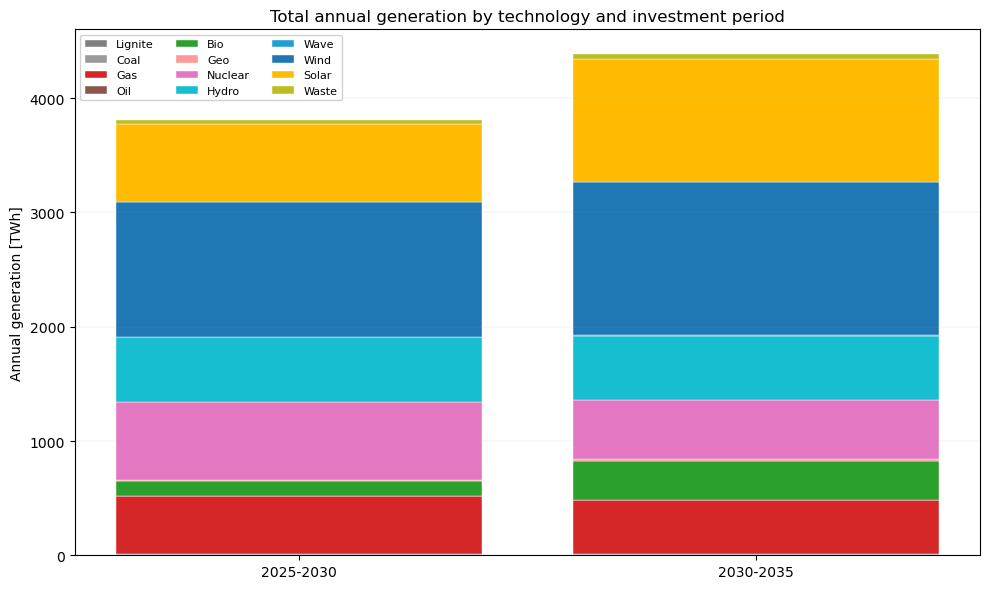

Saved -> ..\Results\basic_run\dataset_ES_GoRES\plots\annual_generation_stacked.png


In [26]:
# ── Plot: annual generation by technology (stacked bar per investment period) ──
# Source: results_output_EuropeSummary.csv
import io


def load_europe_summary_generation(results_path: Path) -> pd.DataFrame:
    csv_path = results_path / "Output" / "results_output_EuropeSummary.csv"
    with csv_path.open("r", encoding="utf-8") as f:
        lines = f.readlines()

    # Locate the GeneratorType header row (first CSV field == "GeneratorType")
    start_idx = None
    for i, line in enumerate(lines):
        first_field = line.strip().split(",")[0].strip().strip('"')
        if first_field == "GeneratorType":
            start_idx = i
            break
    if start_idx is None:
        raise ValueError("Could not find GeneratorType section in results_output_EuropeSummary.csv")

    # Collect rows until we hit a separator (empty line, all-quotes/commas row, or new section)
    section_lines = [lines[start_idx]]
    for line in lines[start_idx + 1:]:
        stripped = line.strip()
        # Separator rows are empty, quoted-empty (""), or only commas/quotes
        if not stripped.strip('",'):
            break
        section_lines.append(line)

    df = pd.read_csv(io.StringIO("".join(section_lines)))
    df["Period"] = df["Period"].astype(str)
    if YEAR_SHIFT:
        df["Period"] = df["Period"].map(lambda x: shift_period_label(x, YEAR_SHIFT))
    df["genExpectedAnnualProduction_GWh"] = pd.to_numeric(
        df["genExpectedAnnualProduction_GWh"], errors="coerce"
    ).fillna(0.0)
    return df


_gen_summary = load_europe_summary_generation(RESULTS_PATH)
_gen_summary["TechGroup"] = _gen_summary["GeneratorType"].map(map_generator_to_group)

_unknown = sorted(_gen_summary.loc[_gen_summary["TechGroup"].isna(), "GeneratorType"].unique())
if _unknown:
    print("Warning: Unmapped technologies skipped:", ", ".join(_unknown))
_gen_summary = _gen_summary.dropna(subset=["TechGroup"])

# Sum over all generator sub-types within each tech group, then pivot
_gen_pivot = (
    _gen_summary
    .groupby(["Period", "TechGroup"])["genExpectedAnnualProduction_GWh"]
    .sum()
    .unstack("TechGroup")
    .fillna(0.0)
    .reindex(columns=TECH_ORDER, fill_value=0.0)
)
_gen_pivot = _gen_pivot.loc[sorted(_gen_pivot.index, key=parse_period_end_year)]

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(_gen_pivot.index))
bottom = np.zeros(len(_gen_pivot))

for tech in TECH_ORDER:
    vals = _gen_pivot[tech].values / 1000.0  # GWh -> TWh
    if vals.sum() == 0:
        continue
    ax.bar(x, vals, bottom=bottom, color=TECH_COLORS[tech], edgecolor="white", linewidth=0.3, label=tech)
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(_gen_pivot.index, rotation=0)
ax.set_ylabel("Annual generation [TWh]")
ax.set_title("Total annual generation by technology and investment period")
ax.legend(ncol=3, fontsize=8, framealpha=0.9)
ax.grid(axis="y", linewidth=0.3, alpha=0.4)
plt.tight_layout()
plt.savefig(PLOT_DIR / "annual_generation_stacked.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {PLOT_DIR / 'annual_generation_stacked.png'}")

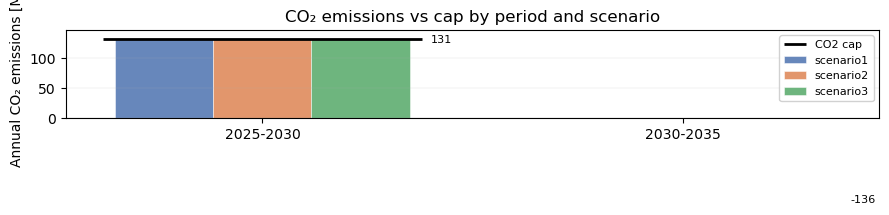

Saved -> ..\Results\basic_run\dataset_ES_GoRES\plots\co2_emissions_vs_cap.png

Constraint check (slack = cap - emission):
   Period  Scenario  emission_Mt      cap_Mt      slack_Mt  CO2Price_EuroPerTon
2025-2030 scenario1   131.282048  131.282048 -4.493188e-10          -180.485576
2025-2030 scenario2   131.282048  131.282048 -1.415401e-11          -128.942314
2025-2030 scenario3   131.282048  131.282048 -4.387175e-10           -61.651299
2030-2035 scenario1  -136.084598 -136.084598 -4.337153e-10           -79.341852
2030-2035 scenario2  -136.084598 -136.084598 -3.769856e-10           -68.554277
2030-2035 scenario3  -136.084598 -136.084598 -4.915250e-10           -79.528366


In [27]:
# ── Plot: CO2 emissions vs cap per period and scenario ──────────────────────
import io


def load_europe_summary_co2(results_path: Path) -> pd.DataFrame:
    csv_path = results_path / "Output" / "results_output_EuropeSummary.csv"
    with csv_path.open("r", encoding="utf-8") as f:
        lines = f.readlines()
    # First section ends at the first separator row
    section_lines = []
    for line in lines:
        if not line.strip().strip('",'):
            break
        section_lines.append(line)
    df = pd.read_csv(io.StringIO("".join(section_lines)))
    df["Period"] = df["Period"].astype(str)
    if YEAR_SHIFT:
        df["Period"] = df["Period"].map(lambda x: shift_period_label(x, YEAR_SHIFT))
    for col in ("AnnualCO2emission_Ton", "CO2Cap_Ton"):
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


_co2 = load_europe_summary_co2(RESULTS_PATH)
_co2["emission_Mt"] = _co2["AnnualCO2emission_Ton"] / 1e6
_co2["cap_Mt"]      = _co2["CO2Cap_Ton"]            / 1e6
_co2["slack_Mt"]    = _co2["cap_Mt"] - _co2["emission_Mt"]

periods   = sorted(_co2["Period"].unique(), key=parse_period_end_year)
scenarios = sorted(_co2["Scenario"].unique())
n_scen    = len(scenarios)
bar_w     = 0.7 / n_scen
scen_colors = ["#4c72b0", "#dd8452", "#55a868", "#c44e52"]

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(periods))

for s_idx, scen in enumerate(scenarios):
    sub = _co2[_co2["Scenario"] == scen].set_index("Period")
    vals = [sub.loc[p, "emission_Mt"] if p in sub.index else float("nan") for p in periods]
    offset = (s_idx - (n_scen - 1) / 2) * bar_w
    ax.bar(x + offset, vals, width=bar_w, color=scen_colors[s_idx % len(scen_colors)],
           label=scen, alpha=0.85, edgecolor="white", linewidth=0.4)

# Cap as horizontal tick marks spanning the full bar group
caps = [_co2.loc[_co2["Period"] == p, "cap_Mt"].iloc[0] for p in periods]
for xi, cap in zip(x, caps):
    ax.hlines(cap, xi - 0.38, xi + 0.38, colors="black", linewidths=2.0, label="CO2 cap" if xi == x[0] else None)
    ax.text(xi + 0.40, cap, f"{cap:.0f}", va="center", ha="left", fontsize=8, color="black")

ax.set_xticks(x)
ax.set_xticklabels(periods, rotation=0)
ax.set_ylabel("Annual CO₂ emissions [Mt]")
ax.set_title("CO₂ emissions vs cap by period and scenario")
ax.legend(fontsize=8, framealpha=0.9)
ax.grid(axis="y", linewidth=0.3, alpha=0.4)
ax.set_ylim(0, max(caps) * 1.12)
plt.tight_layout()
plt.savefig(PLOT_DIR / "co2_emissions_vs_cap.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {PLOT_DIR / 'co2_emissions_vs_cap.png'}")
print()
print("Constraint check (slack = cap - emission):")
print(_co2[["Period","Scenario","emission_Mt","cap_Mt","slack_Mt","CO2Price_EuroPerTon"]].to_string(index=False))